In [1]:
from SEPOT import SEPOT
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import kstest, expon, probplot
from simulate_SE_POT import simulate_SE_POT
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


%config InlineBackend.figure_format = 'retina'
pd.options.display.float_format = '{:.5f}'.format
np.set_printoptions(precision=5, suppress=True)

In [2]:
GSPC_full_data = yf.download("^GSPC",
                             start="1957-01-02",
                             end="2010-01-01")

#2013-01-01


GSPC_full_data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1957-01-02,46.20000,46.20000,46.20000,46.20000,1960000
1957-01-03,46.60000,46.60000,46.60000,46.60000,2260000
1957-01-04,46.66000,46.66000,46.66000,46.66000,2710000
1957-01-07,46.42000,46.42000,46.42000,46.42000,2500000
1957-01-08,46.25000,46.25000,46.25000,46.25000,2230000
...,...,...,...,...,...
2009-12-24,1126.47998,1126.47998,1121.07996,1121.07996,1267710000
2009-12-28,1127.78003,1130.38000,1123.51001,1127.53003,2716400000


In [3]:
GSPC_ret_full_data = (GSPC_full_data["Close"].pct_change() * 100)[1:]

GSPC_ret_full_data["t"] = np.arange(start=1,
                                    stop=len(GSPC_ret_full_data) + 1,
                                    step=1)

GSPC_ret_full_data

Ticker,^GSPC,t
Date,,
1957-01-03,0.86580,1
1957-01-04,0.12876,2
1957-01-07,-0.51436,3
1957-01-08,-0.36622,4
1957-01-09,-0.19459,5
...,...,...
2009-12-24,0.52562,13338
2009-12-28,0.11541,13339
2009-12-29,-0.14011,13340


In [4]:
train_end_date = "2008-08-29"

GSPC_ret_train = GSPC_ret_full_data.loc[:train_end_date]

T_train = GSPC_ret_train["t"].iloc[-1].item()

GSPC_ret_train

Ticker,^GSPC,t
Date,,
1957-01-03,0.86580,1
1957-01-04,0.12876,2
1957-01-07,-0.51436,3
1957-01-08,-0.36622,4
1957-01-09,-0.19459,5
...,...,...
2008-08-25,-1.96254,13001
2008-08-26,0.36864,13002
2008-08-27,0.79827,13003


In [5]:
test_start_date = "2008-09-02"

GSPC_ret_test = GSPC_ret_full_data.loc[test_start_date:]

T_test = GSPC_ret_test["t"].iloc[-1].item()

GSPC_ret_test

Ticker,^GSPC,t
Date,,
2008-09-02,-0.40925,13006
2008-09-03,-0.20351,13007
2008-09-04,-2.99221,13008
2008-09-05,0.44308,13009
2008-09-08,2.05102,13010
...,...,...
2009-12-24,0.52562,13338
2009-12-28,0.11541,13339
2009-12-29,-0.14011,13340


In [6]:
boom_M0 = GSPC_ret_train["^GSPC"].quantile(q=0.95).item()

crash_M0 = GSPC_ret_train["^GSPC"].quantile(q=0.05).item()


GSPC_booms_train = GSPC_ret_train[GSPC_ret_train["^GSPC"].to_numpy() > boom_M0]

GSPC_crashes_train = GSPC_ret_train[GSPC_ret_train["^GSPC"].to_numpy() < crash_M0]


GSPC_booms_test= GSPC_ret_test[GSPC_ret_test["^GSPC"].to_numpy() > boom_M0]

GSPC_crashes_test = GSPC_ret_test[GSPC_ret_test["^GSPC"].to_numpy() < crash_M0]

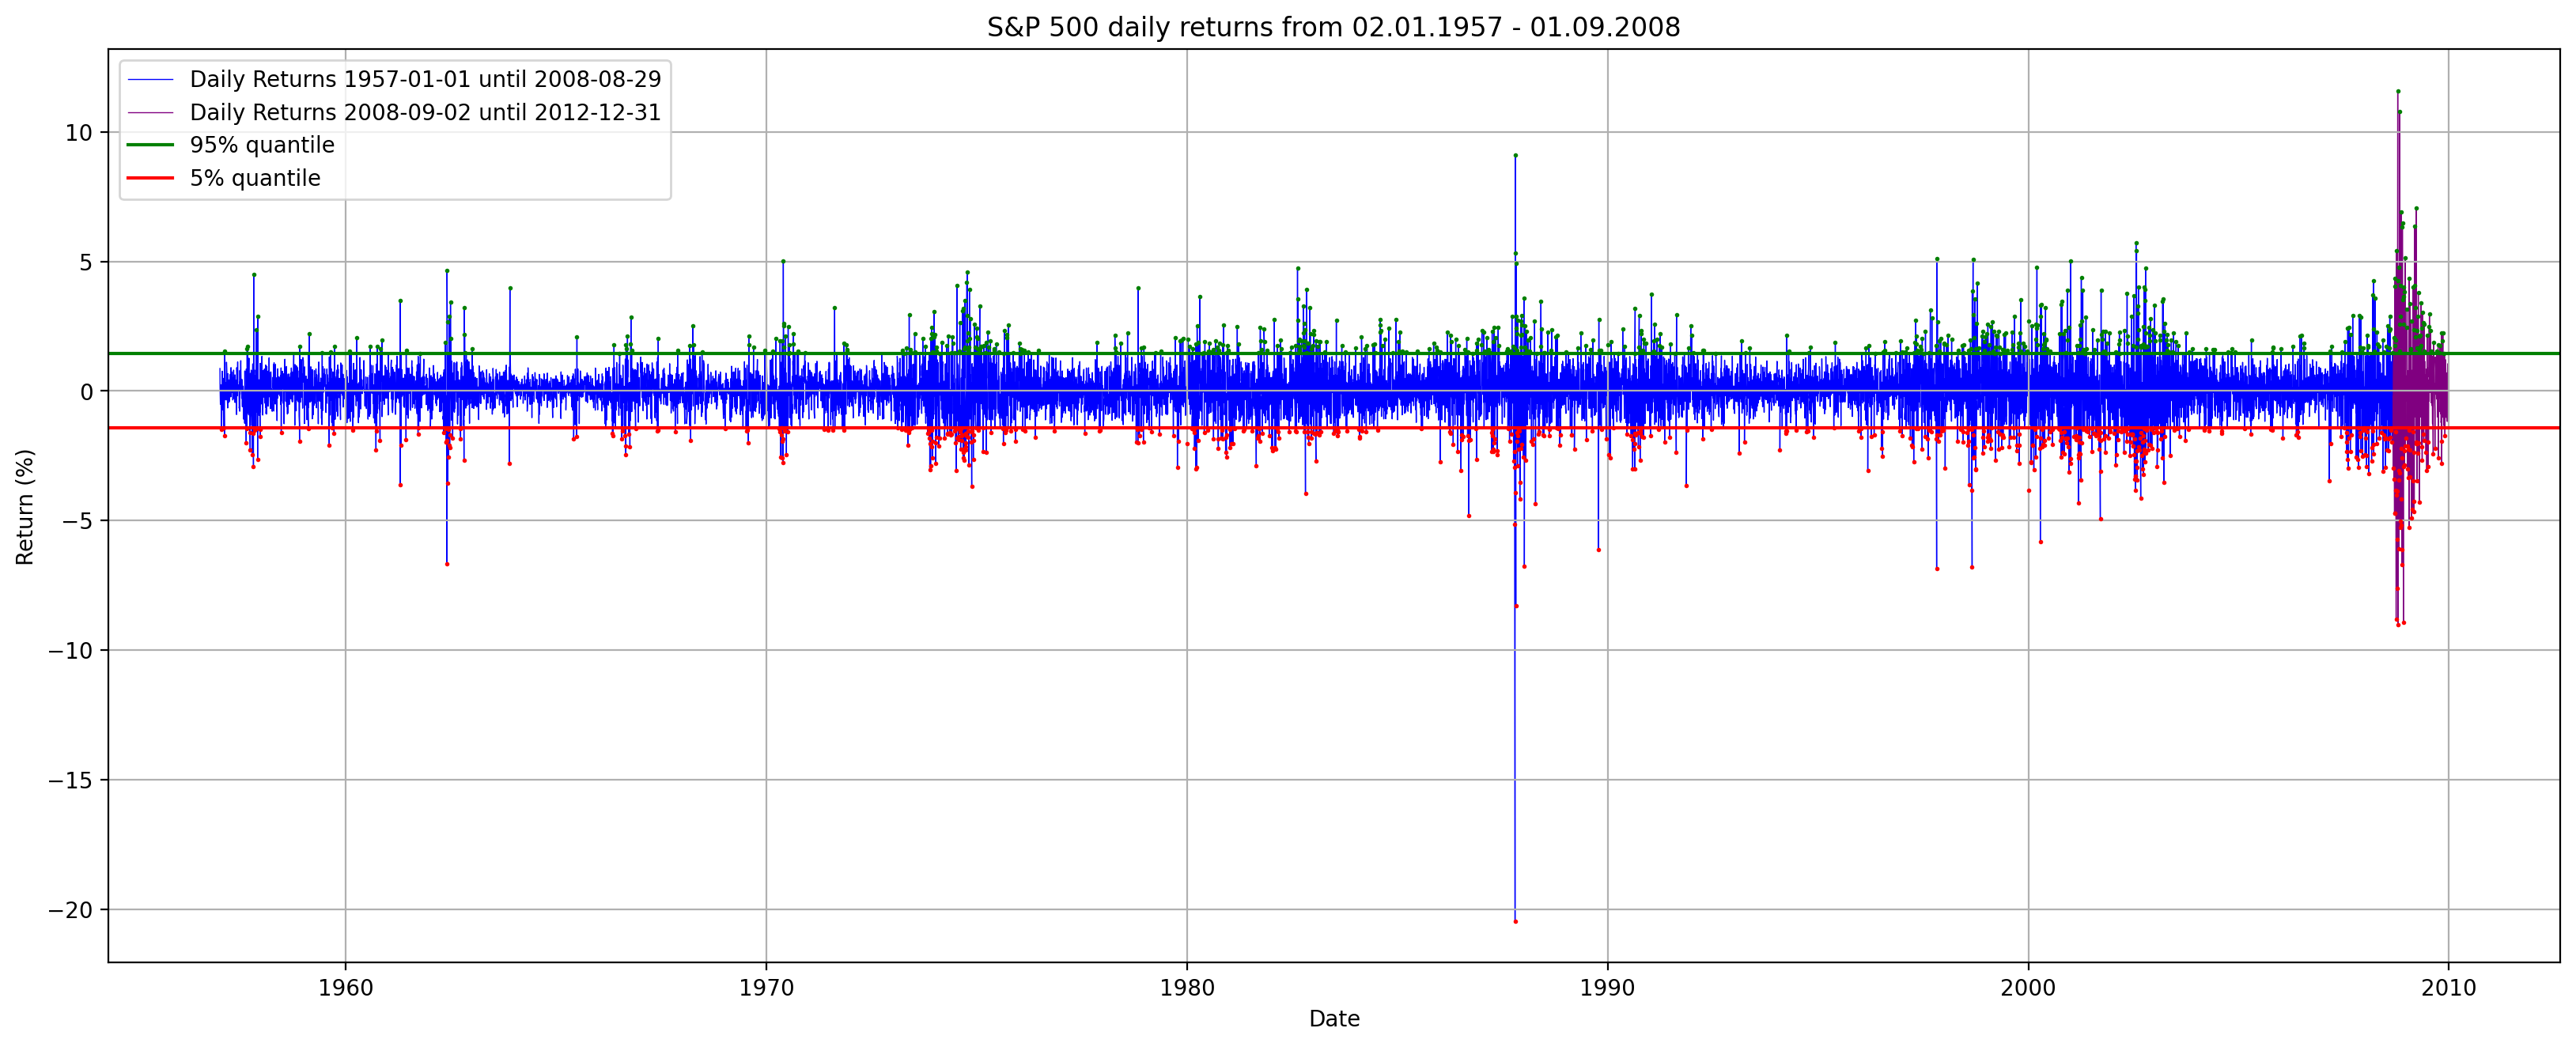

In [7]:
plt.figure(figsize=(20, 7.5),
           dpi=100)

plt.plot(GSPC_ret_train.index,
         GSPC_ret_train["^GSPC"],
         label="Daily Returns 1957-01-01 until 2008-08-29",
         color="blue",
         zorder=1,
         linewidth=0.5)

plt.plot(GSPC_ret_test.index,
         GSPC_ret_test["^GSPC"],
         label="Daily Returns 2008-09-02 until 2012-12-31",
         color="purple",
         zorder=1,
         linewidth=0.5)

plt.scatter(x=GSPC_booms_train.index,
            y=GSPC_booms_train["^GSPC"],
            color="green",
            s=1,
            zorder=2)

plt.scatter(x=GSPC_crashes_train.index,
            y=GSPC_crashes_train["^GSPC"],
            color="red",
            s=1,
            zorder=2)

plt.scatter(x=GSPC_booms_test.index,
            y=GSPC_booms_test["^GSPC"],
            color="green",
            s=1,
            zorder=2)

plt.scatter(x=GSPC_crashes_test.index,
            y=GSPC_crashes_test["^GSPC"],
            color="red",
            s=1,
            zorder=2)

plt.axhline(y=boom_M0,
            color="green",
            label="95% quantile",
            zorder=2)

plt.axhline(y=crash_M0,
            color="red",
            label="5% quantile",
            zorder=2)

plt.title("S&P 500 daily returns from 02.01.1957 - 01.09.2008")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
def set_bounds(SE_fun,
               impact_fun,
               mark_dist,
               zero_lb: float = 1e-05,
               ub: float = np.inf,
               ub_power: float = np.inf,
               xi_pos: bool = False):
    
    bounds = 3 * [(zero_lb, ub)]
    if SE_fun == "Pow":
        bounds += [(zero_lb, ub_power)]
    if impact_fun is not None:
        bounds += [(zero_lb, ub_power)]
    if mark_dist == "GPD":
        if xi_pos:
            bounds += [(zero_lb, ub), (zero_lb, ub)]
        else:
            bounds += [(-ub, ub), (zero_lb, ub)]
    else:
        if xi_pos:
            bounds += [(zero_lb, ub), (zero_lb, ub), (zero_lb, ub)]
        else:
            bounds += [(-ub, ub), (zero_lb, ub), (zero_lb, ub)]
    return bounds

In [9]:
arrival_times_booms_train = GSPC_booms_train["t"].values
arrival_times_crashes_train = GSPC_crashes_train["t"].values

marks_booms_train = GSPC_booms_train["^GSPC"].values
marks_crashes_train = GSPC_crashes_train["^GSPC"].values


arrival_times_booms_test = GSPC_booms_test["t"].values
arrival_times_crashes_test = GSPC_crashes_test["t"].values

marks_booms_test = GSPC_booms_test["^GSPC"].values
marks_crashes_test = GSPC_crashes_test["^GSPC"].values

Fitting model: Exp, None, GPD...
Fitted model: Exp, None, GPD!


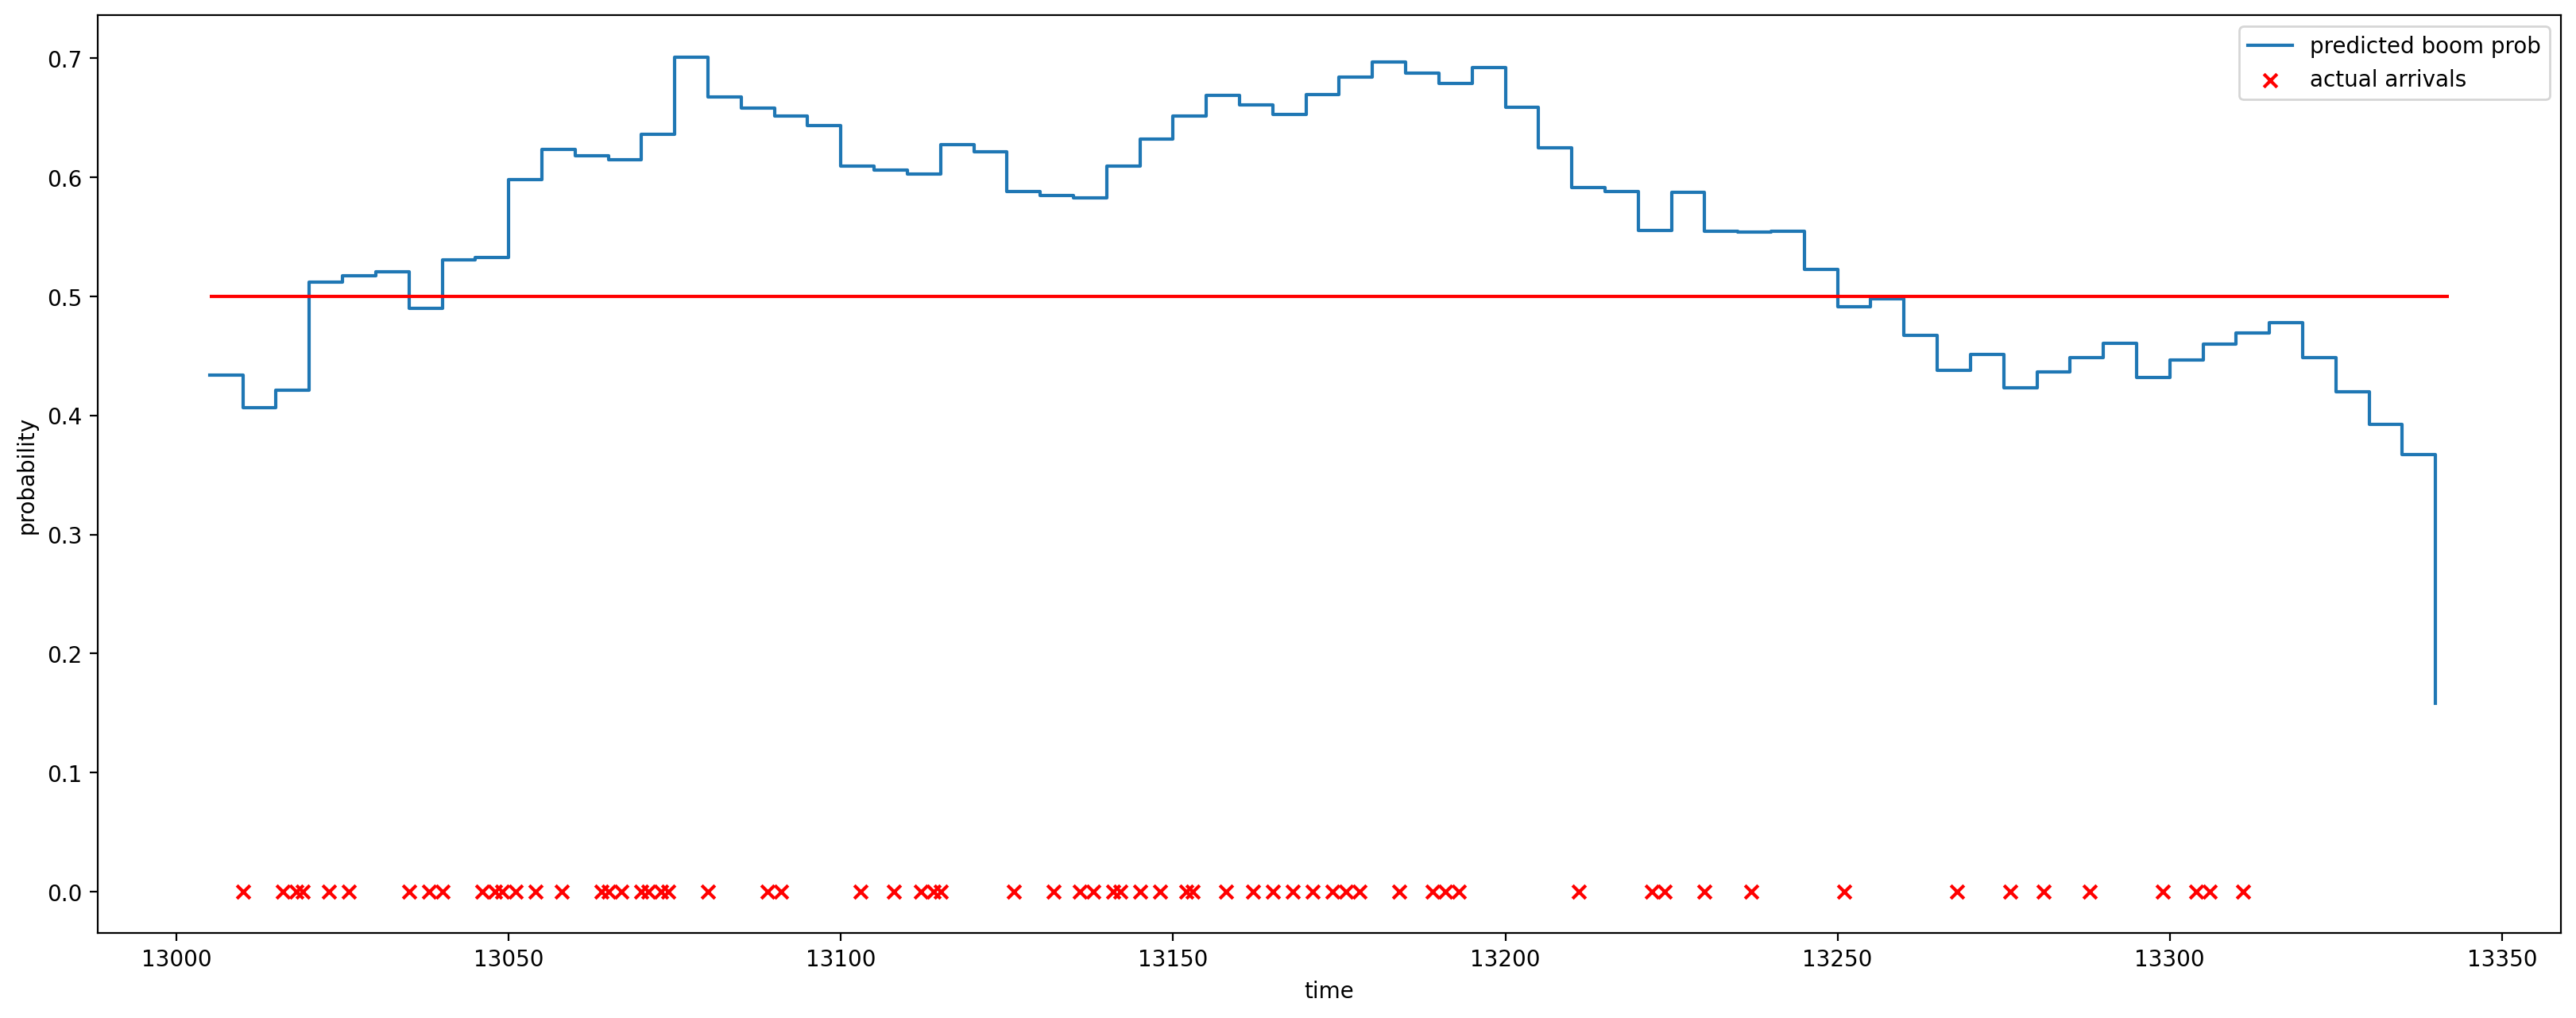

Estimated model parameters: [0.00919 0.01582 0.01917 0.15396 0.56765]
Log-likelihood: -2793.745700927776
QPS: 0.4392364506012563
LPS: 0.6302148777619253
--------------------------------------------------
Fitting model: Exp, Exp, GPD...
Fitted model: Exp, Exp, GPD!


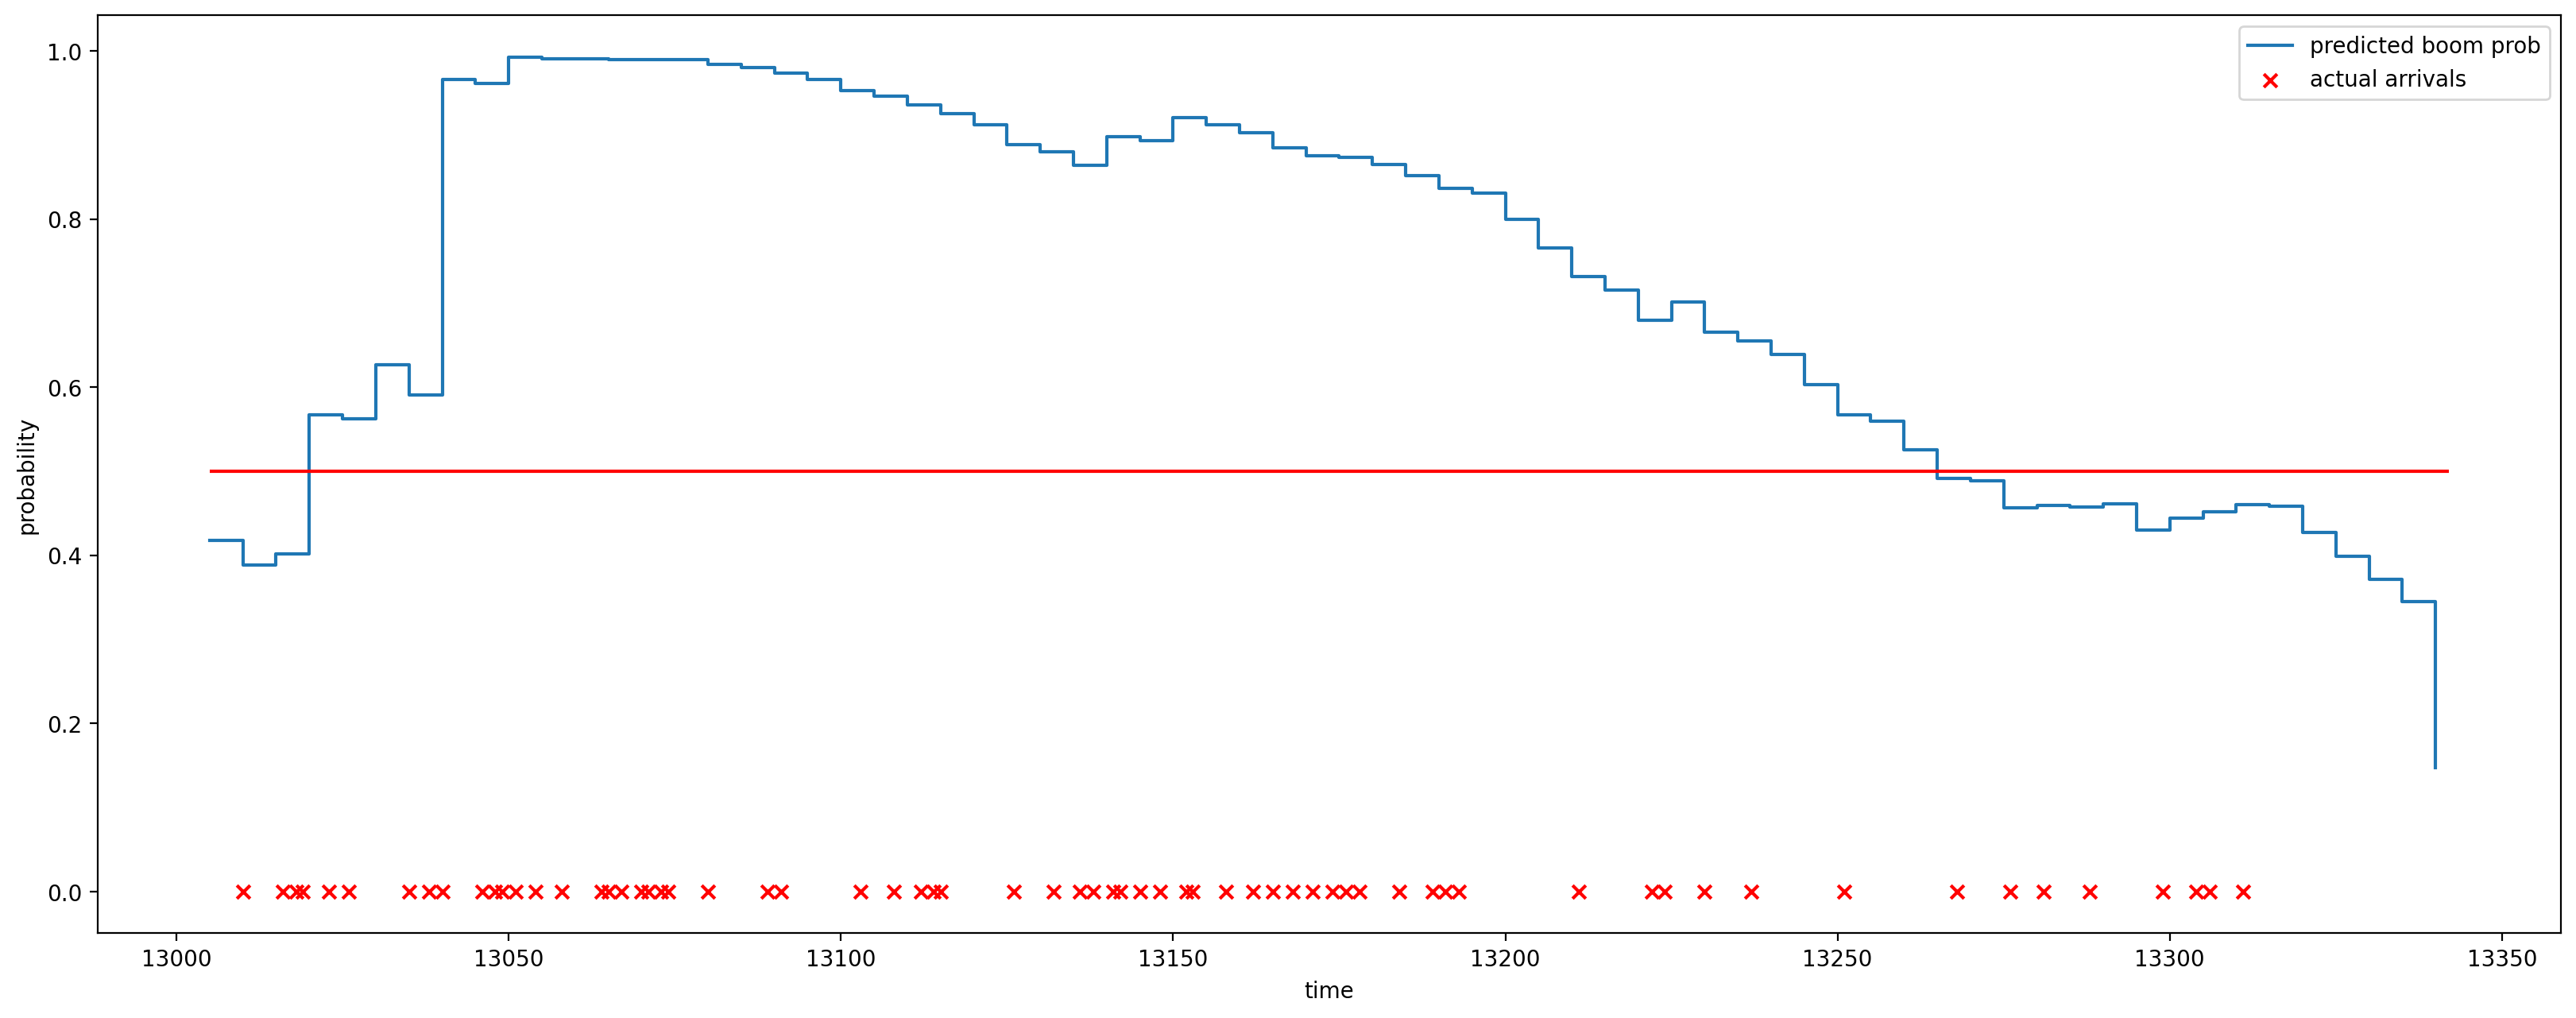

Estimated model parameters: [0.0113  0.01186 0.02085 0.38156 0.15396 0.56765]
Log-likelihood: -2782.882076262815
QPS: 0.39216126024721315
LPS: 0.6008223068862037
--------------------------------------------------
Fitting model: Exp, Pow, GPD...
Fitted model: Exp, Pow, GPD!


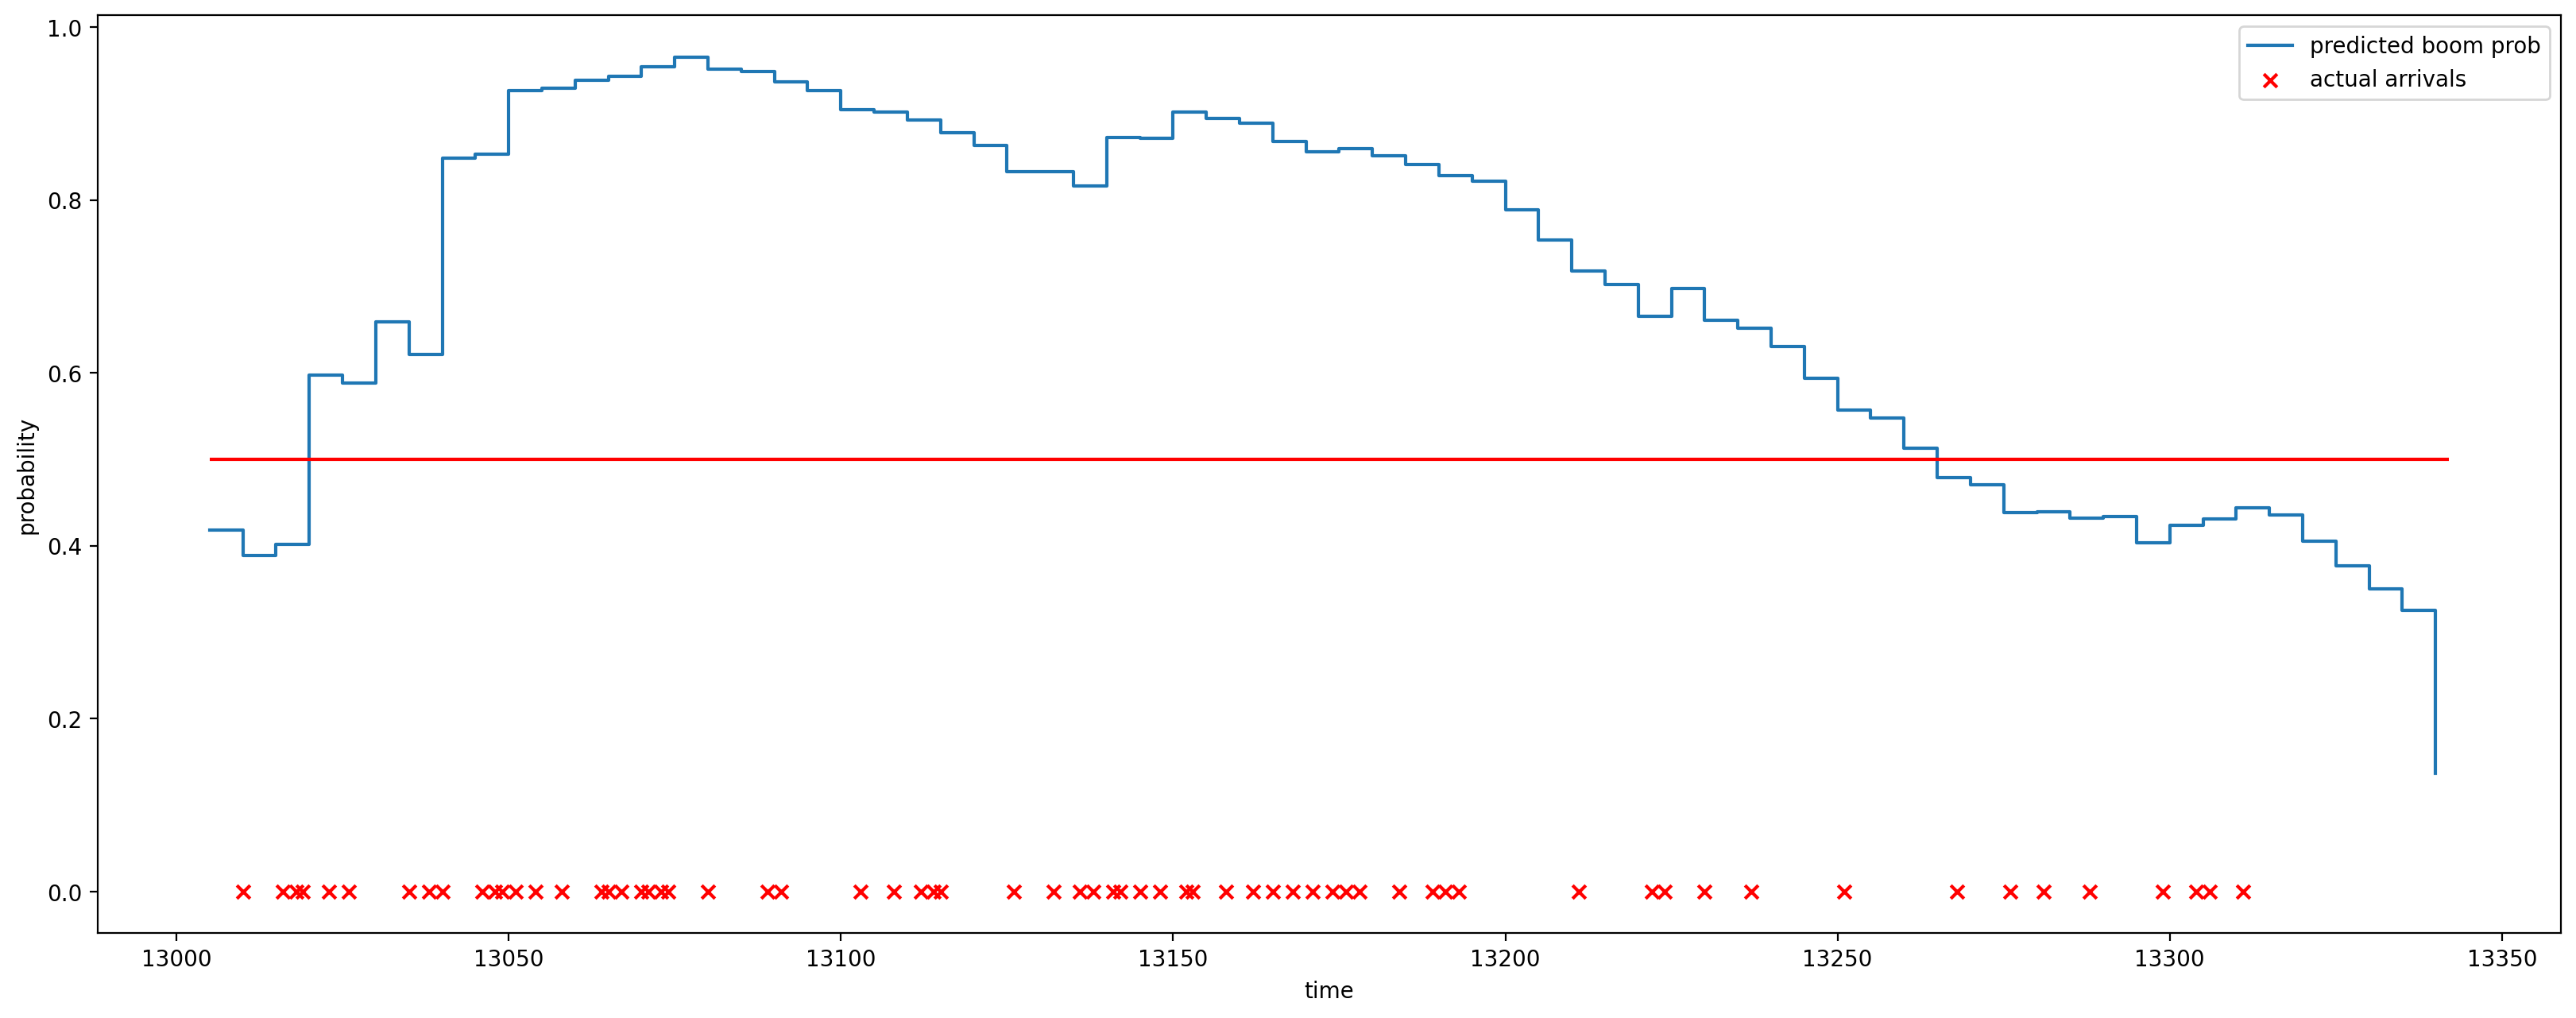

Estimated model parameters: [0.01246 0.00901 0.02161 1.46422 0.15396 0.56765]
Log-likelihood: -2780.9422158806265
QPS: 0.38945192227843756
LPS: 0.5796391720094168
--------------------------------------------------
Fitting model: Exp, None, SE GPD...
Fitted model: Exp, None, SE GPD!


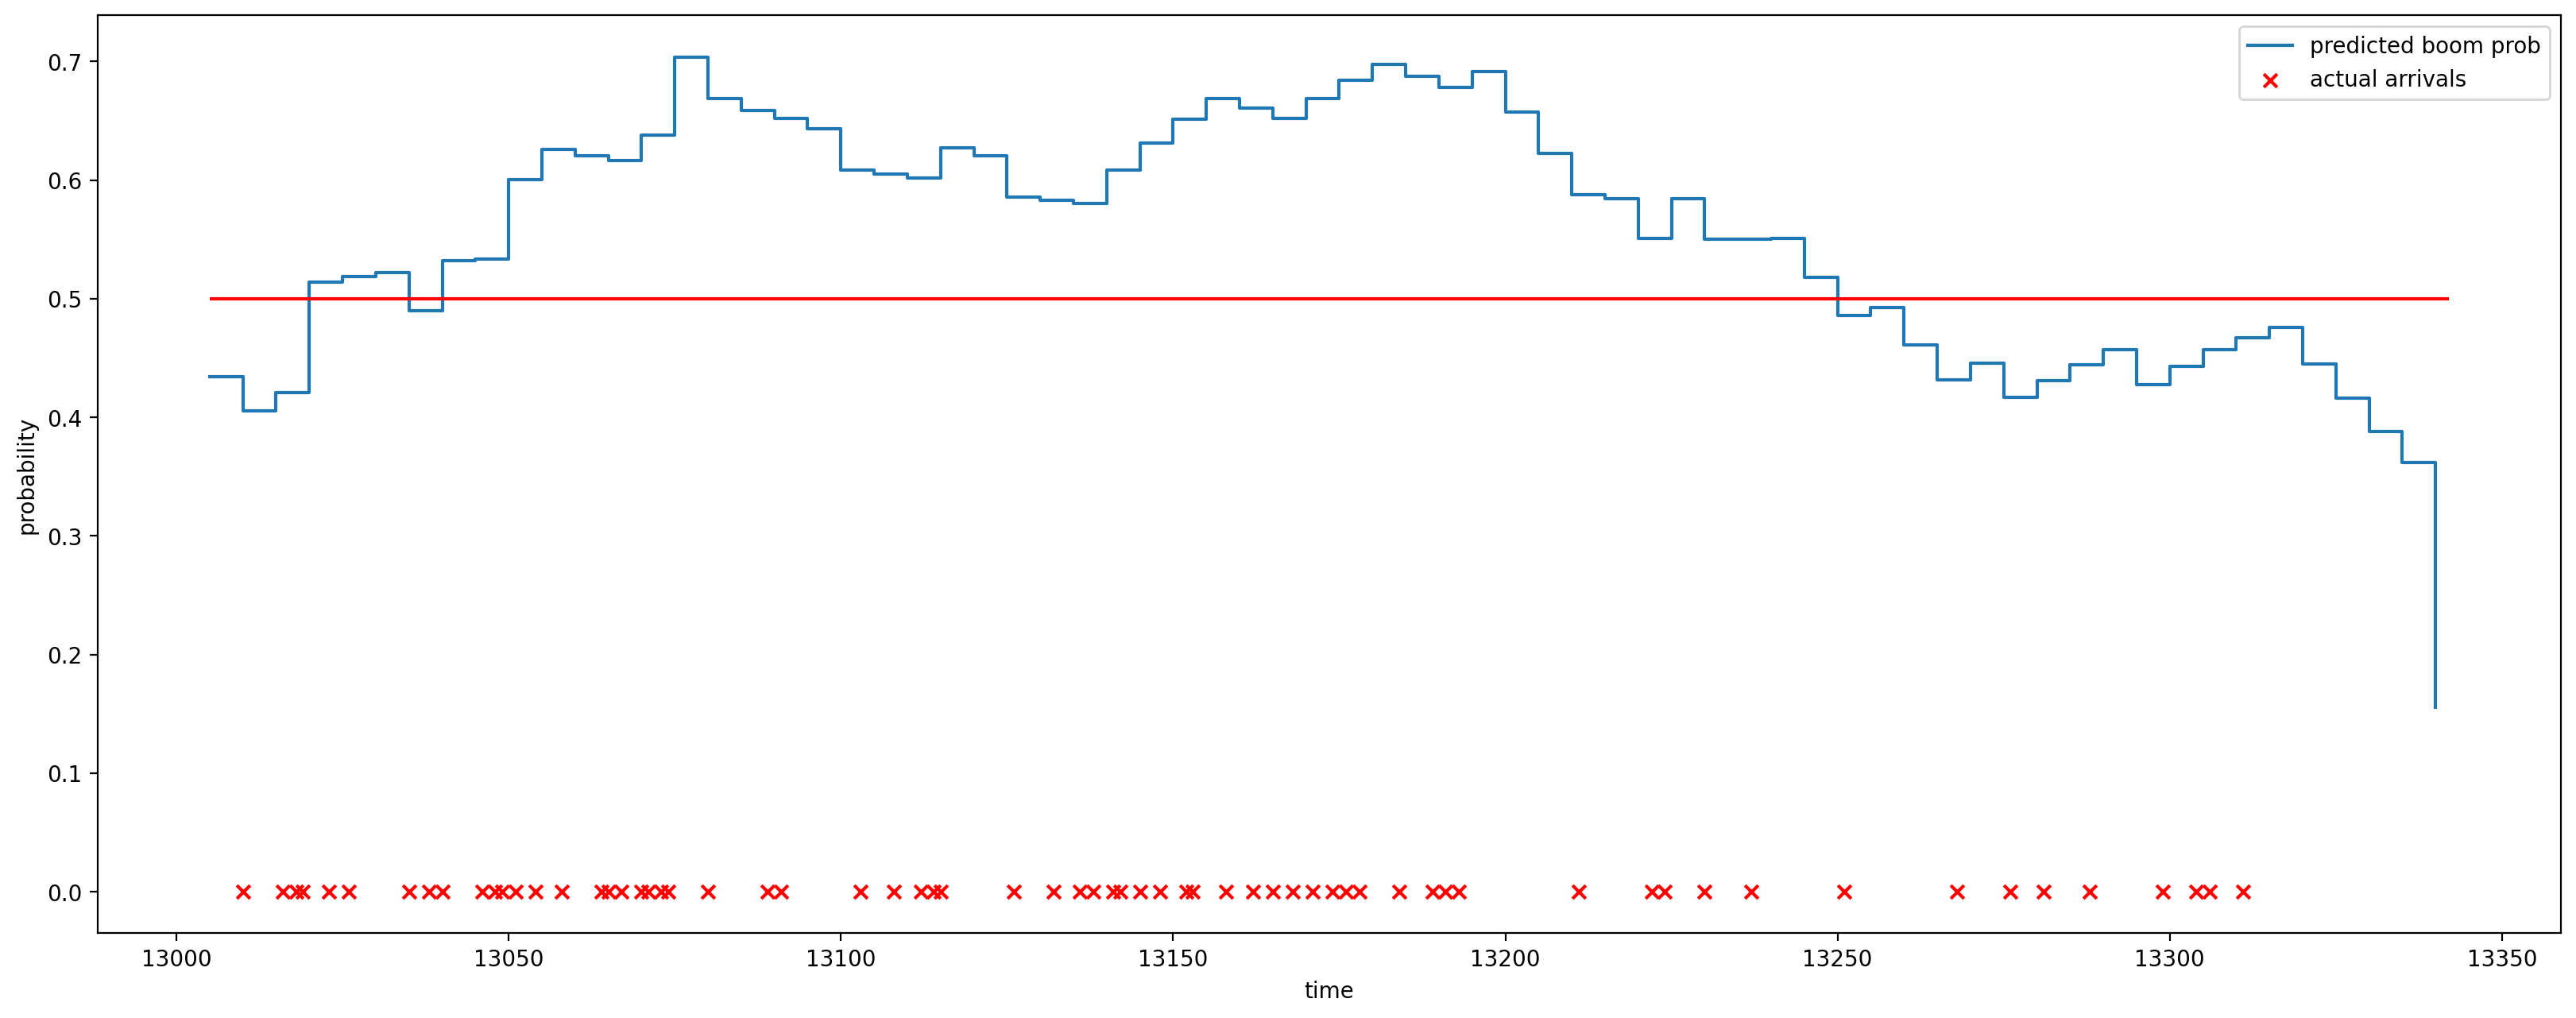

Estimated model parameters: [0.00935 0.01631 0.01985 0.14416 0.37227 2.82623]
Log-likelihood: -2782.646531284329
QPS: 0.4393897961987137
LPS: 0.6303442975118639
--------------------------------------------------
Fitting model: Exp, Exp, SE GPD...
Fitted model: Exp, Exp, SE GPD!


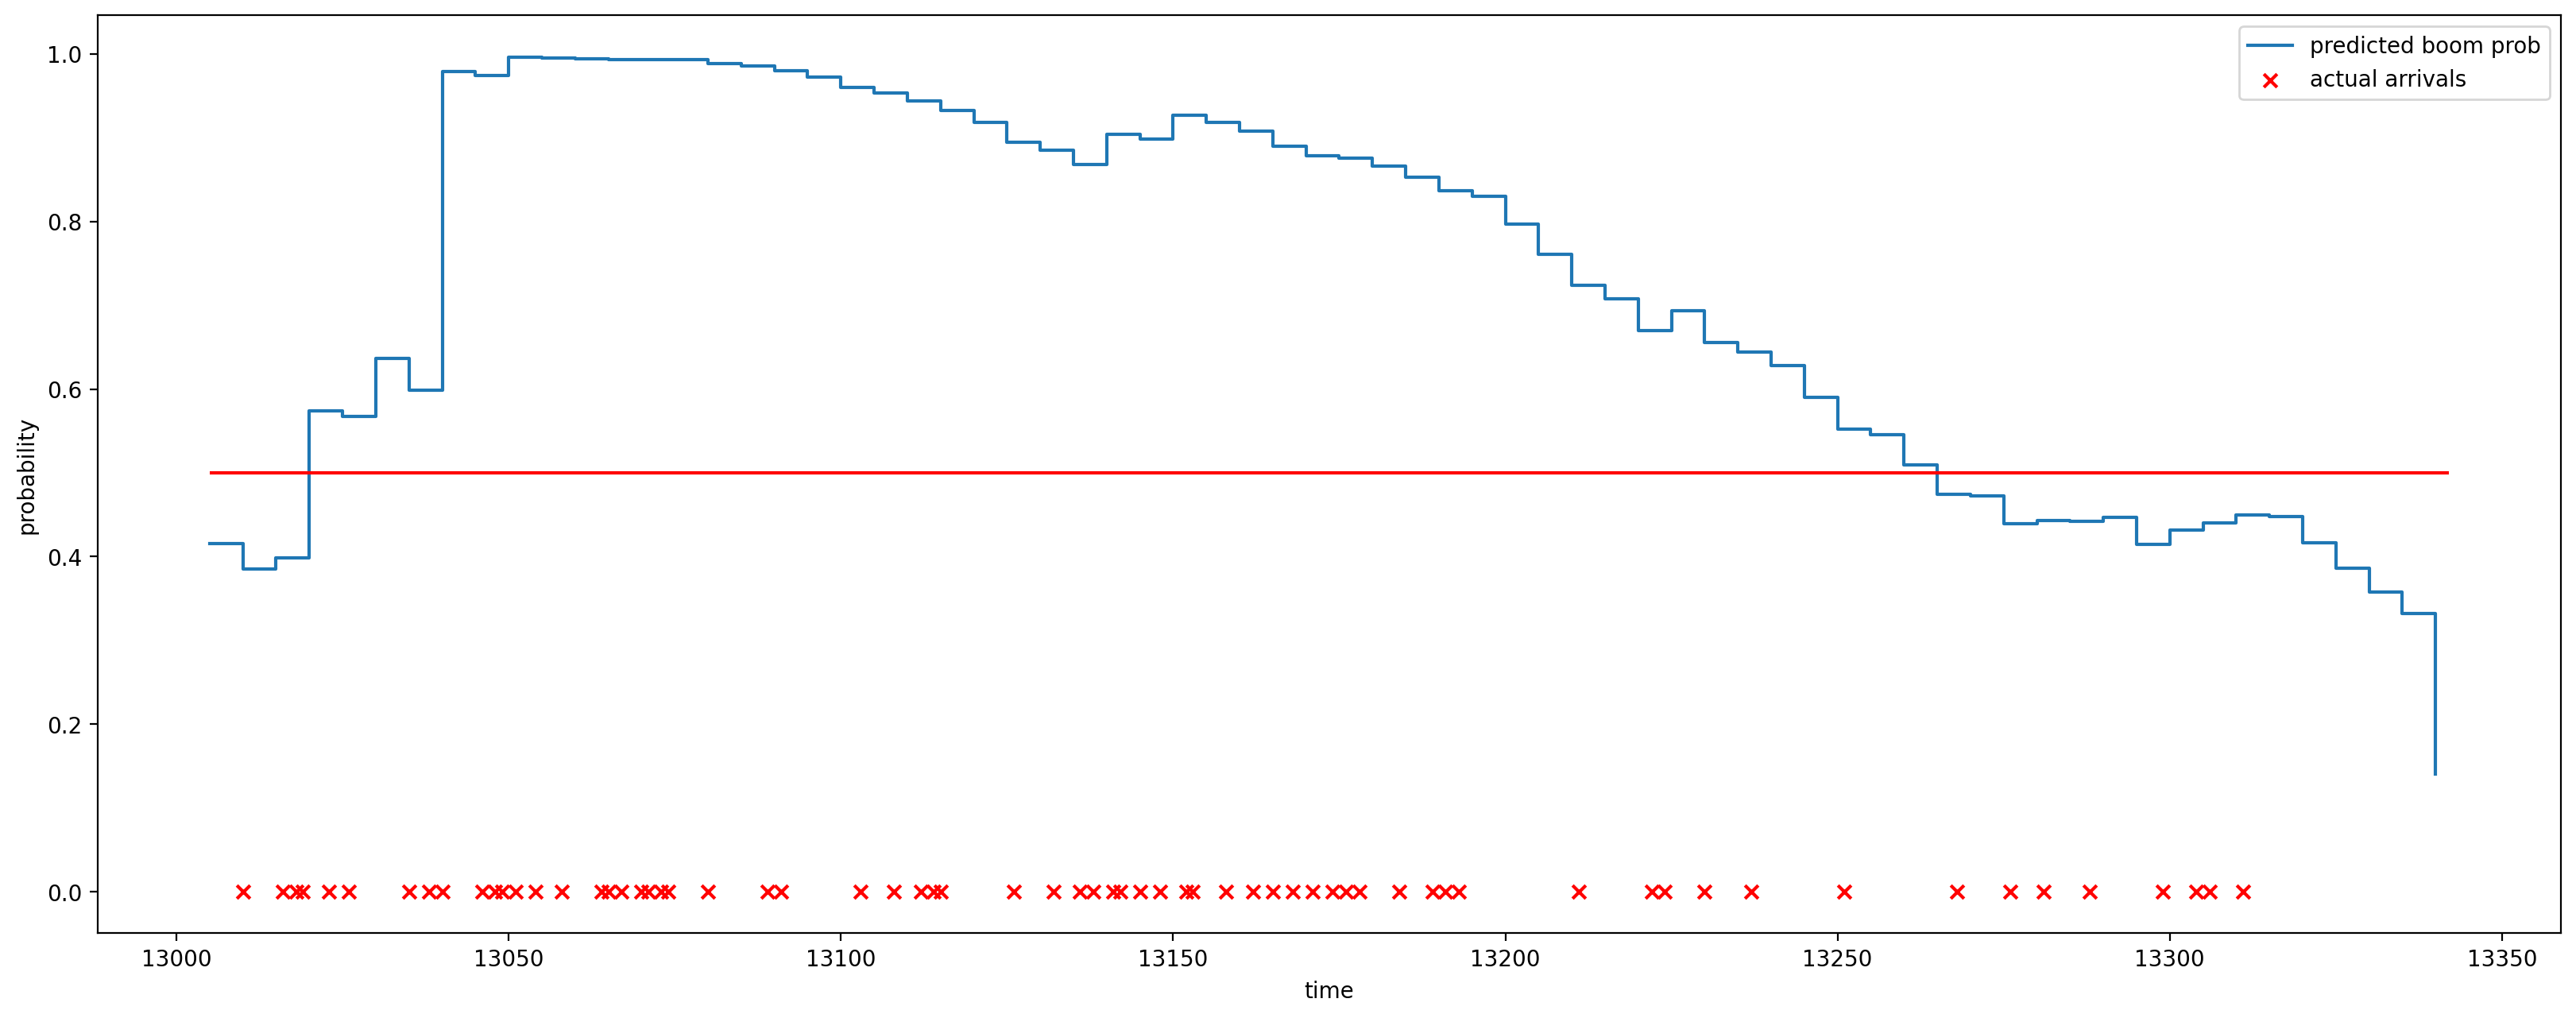

Estimated model parameters: [0.01169 0.01225 0.0221  0.39564 0.13865 0.38568 2.54929]
Log-likelihood: -2767.5762630559434
QPS: 0.3923189757879072
LPS: 0.6082210856302993
--------------------------------------------------
Fitting model: Exp, Pow, SE GPD...
Fitted model: Exp, Pow, SE GPD!


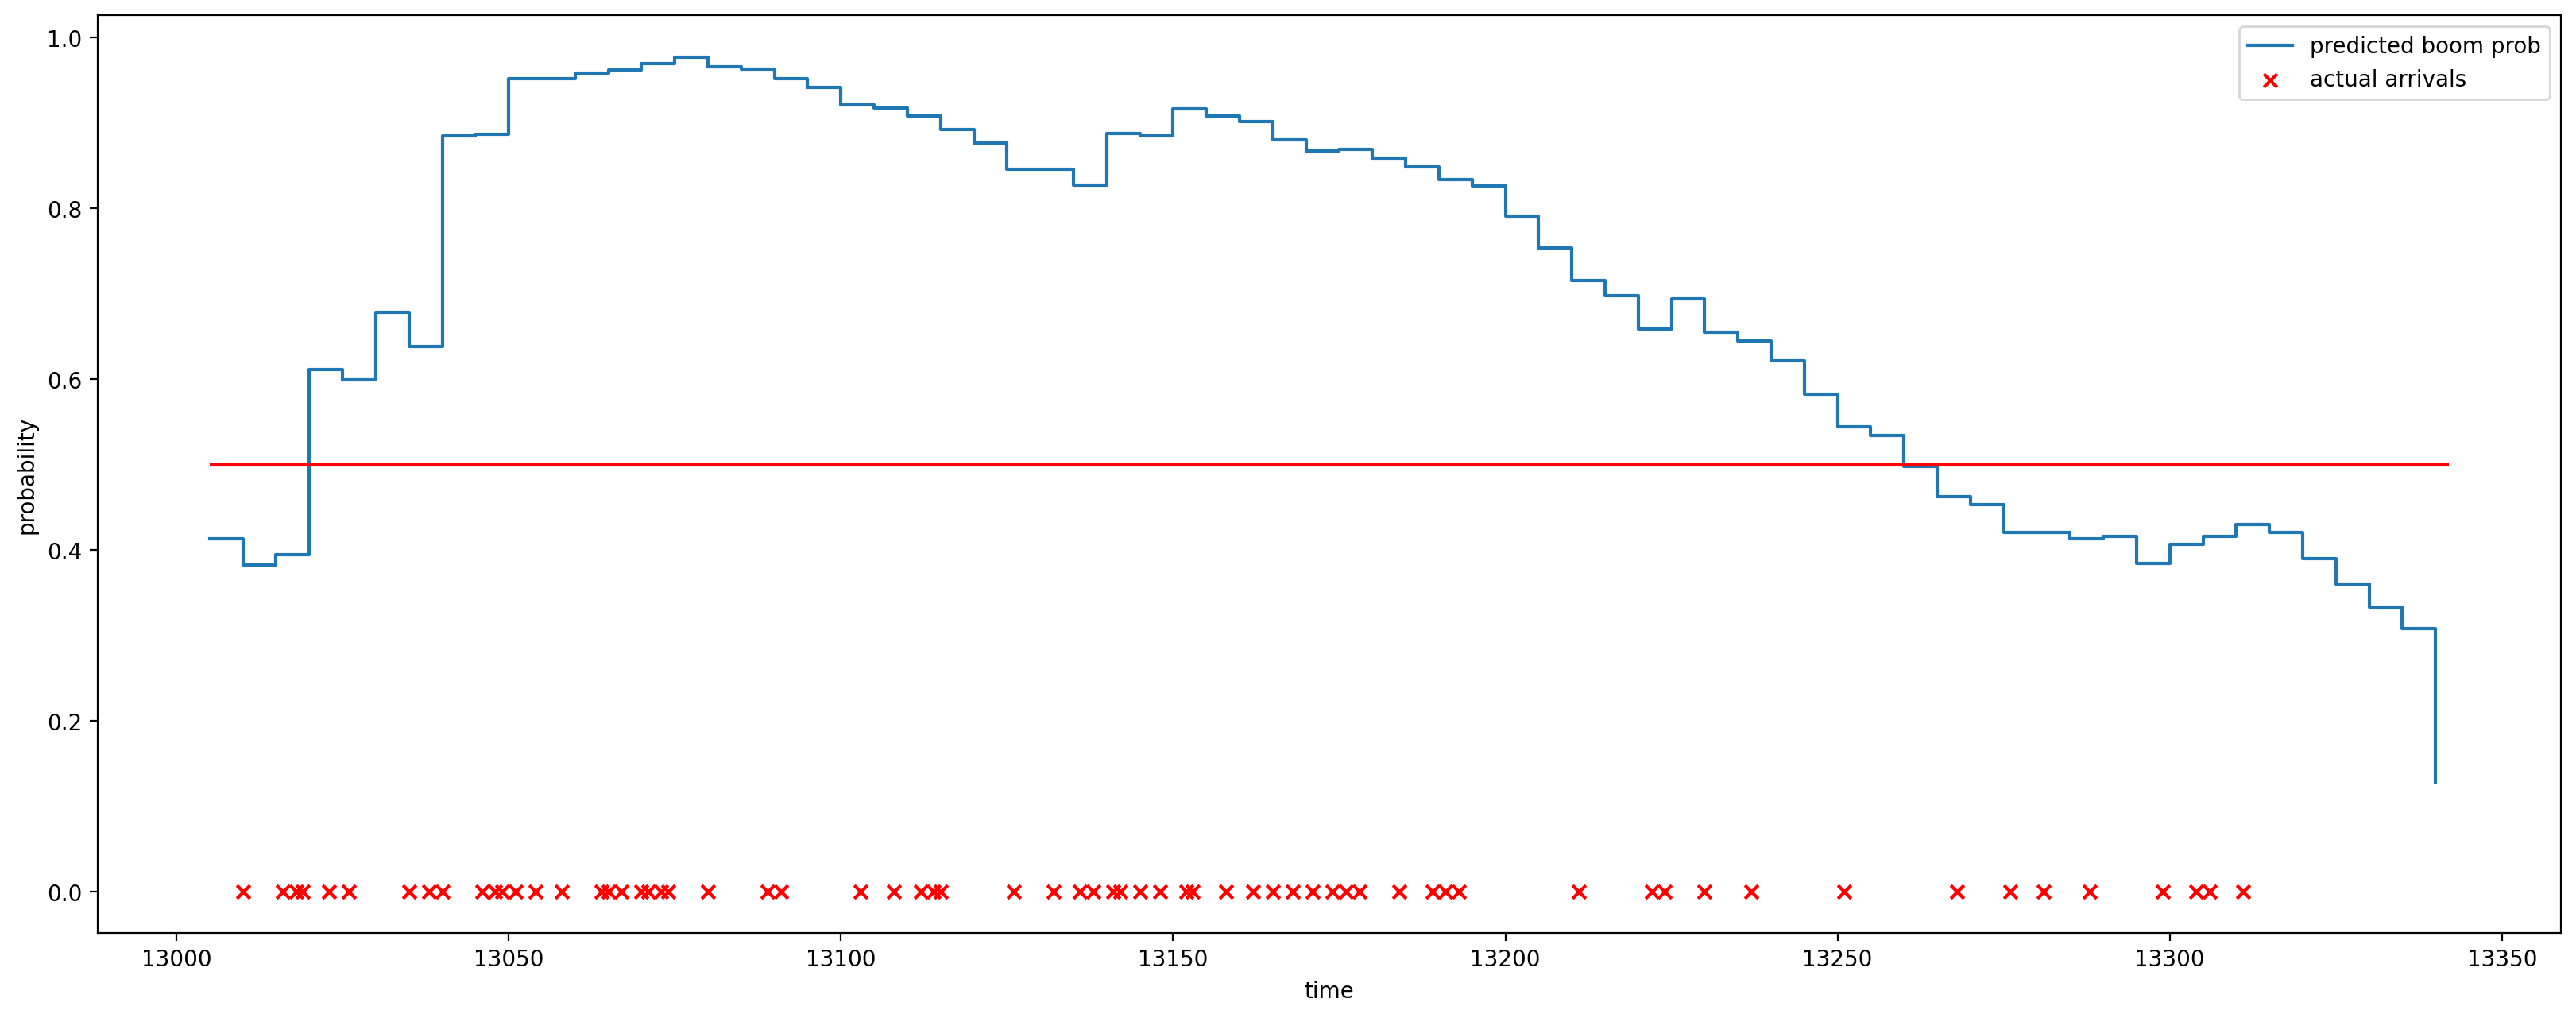

Estimated model parameters: [0.01319 0.00884 0.02308 1.59122 0.13595 0.39099 2.49642]
Log-likelihood: -2764.7728834056306
QPS: 0.3902445282771127
LPS: 0.5846395883166231
--------------------------------------------------
Fitting model: Pow, None, GPD...
Fitted model: Pow, None, GPD!


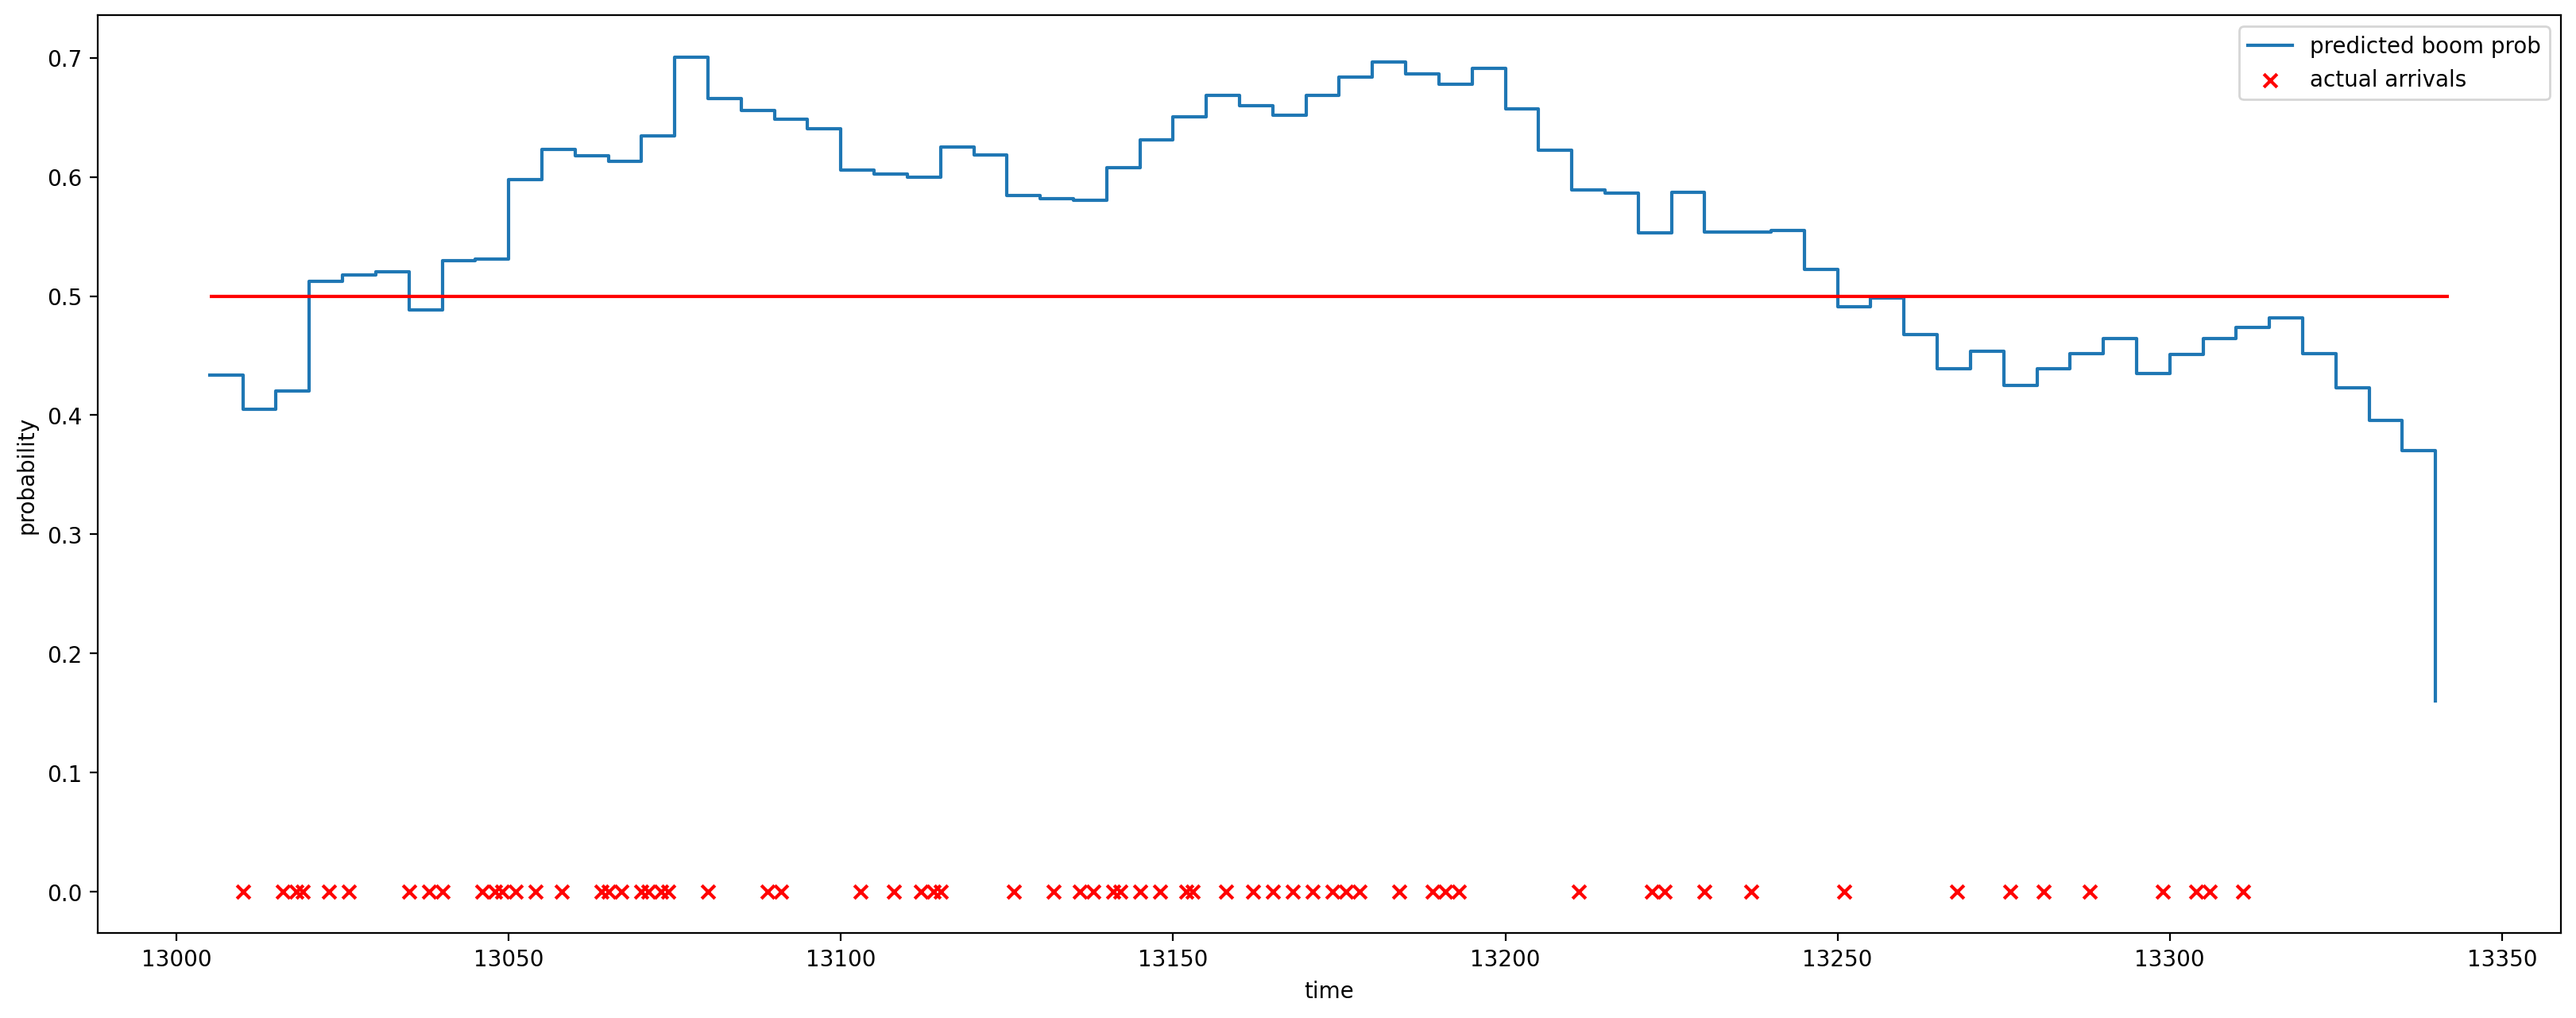

Estimated model parameters: [ 0.00901  0.01623  0.00128 15.28626  0.15396  0.56765]
Log-likelihood: -2793.722320130629
QPS: 0.4397565312242921
LPS: 0.6307808298415568
--------------------------------------------------
Fitting model: Pow, Exp, GPD...
Fitted model: Pow, Exp, GPD!


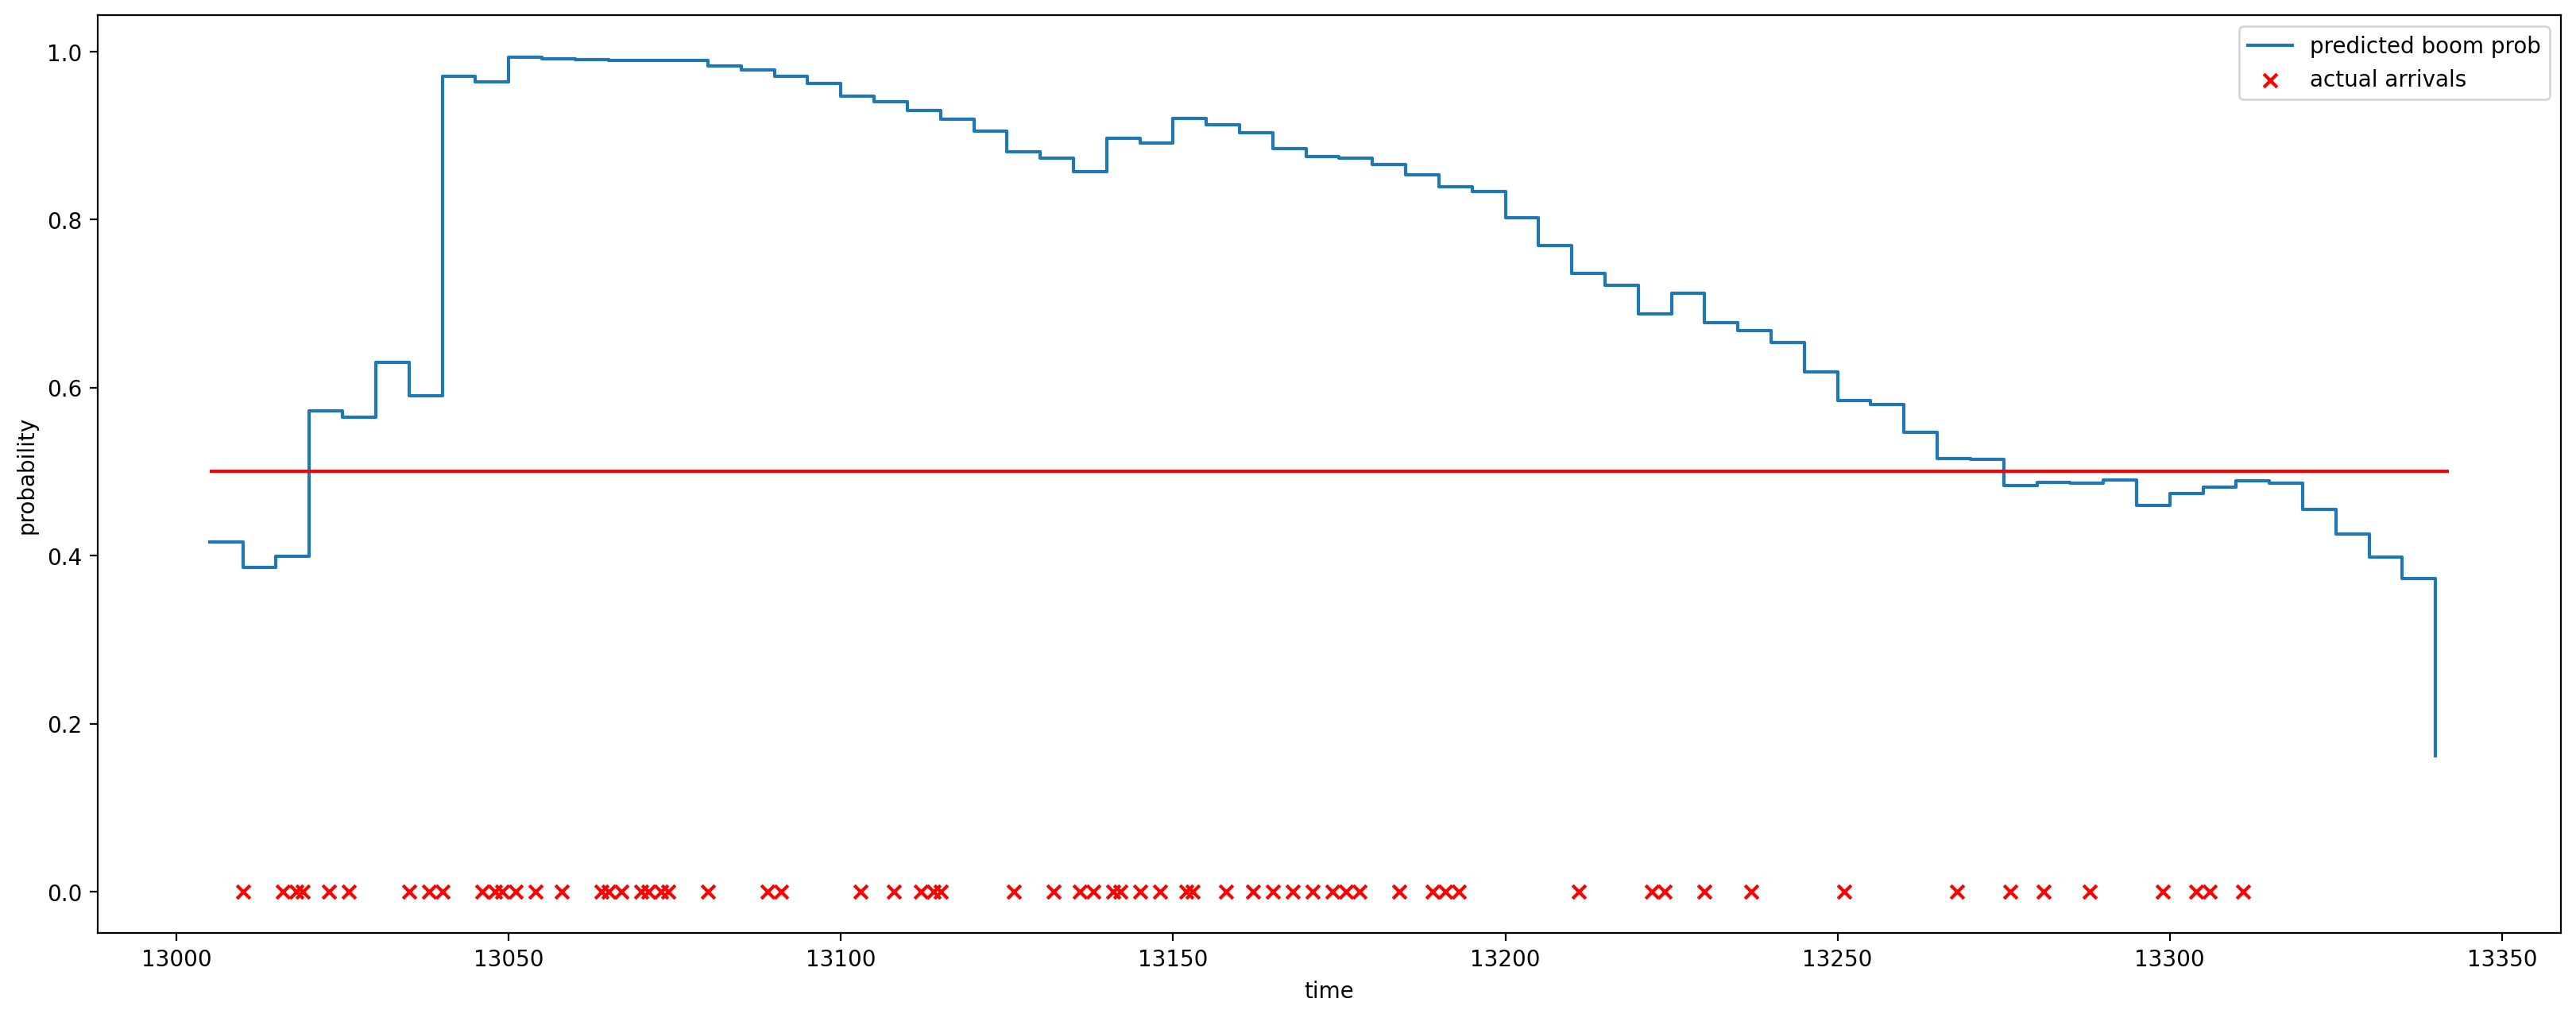

Estimated model parameters: [0.01095 0.01257 0.00317 6.91841 0.38358 0.15396 0.56765]
Log-likelihood: -2782.767393096607
QPS: 0.3922785893452306
LPS: 0.5991257701496483
--------------------------------------------------
Fitting model: Pow, Pow, GPD...
Fitted model: Pow, Pow, GPD!


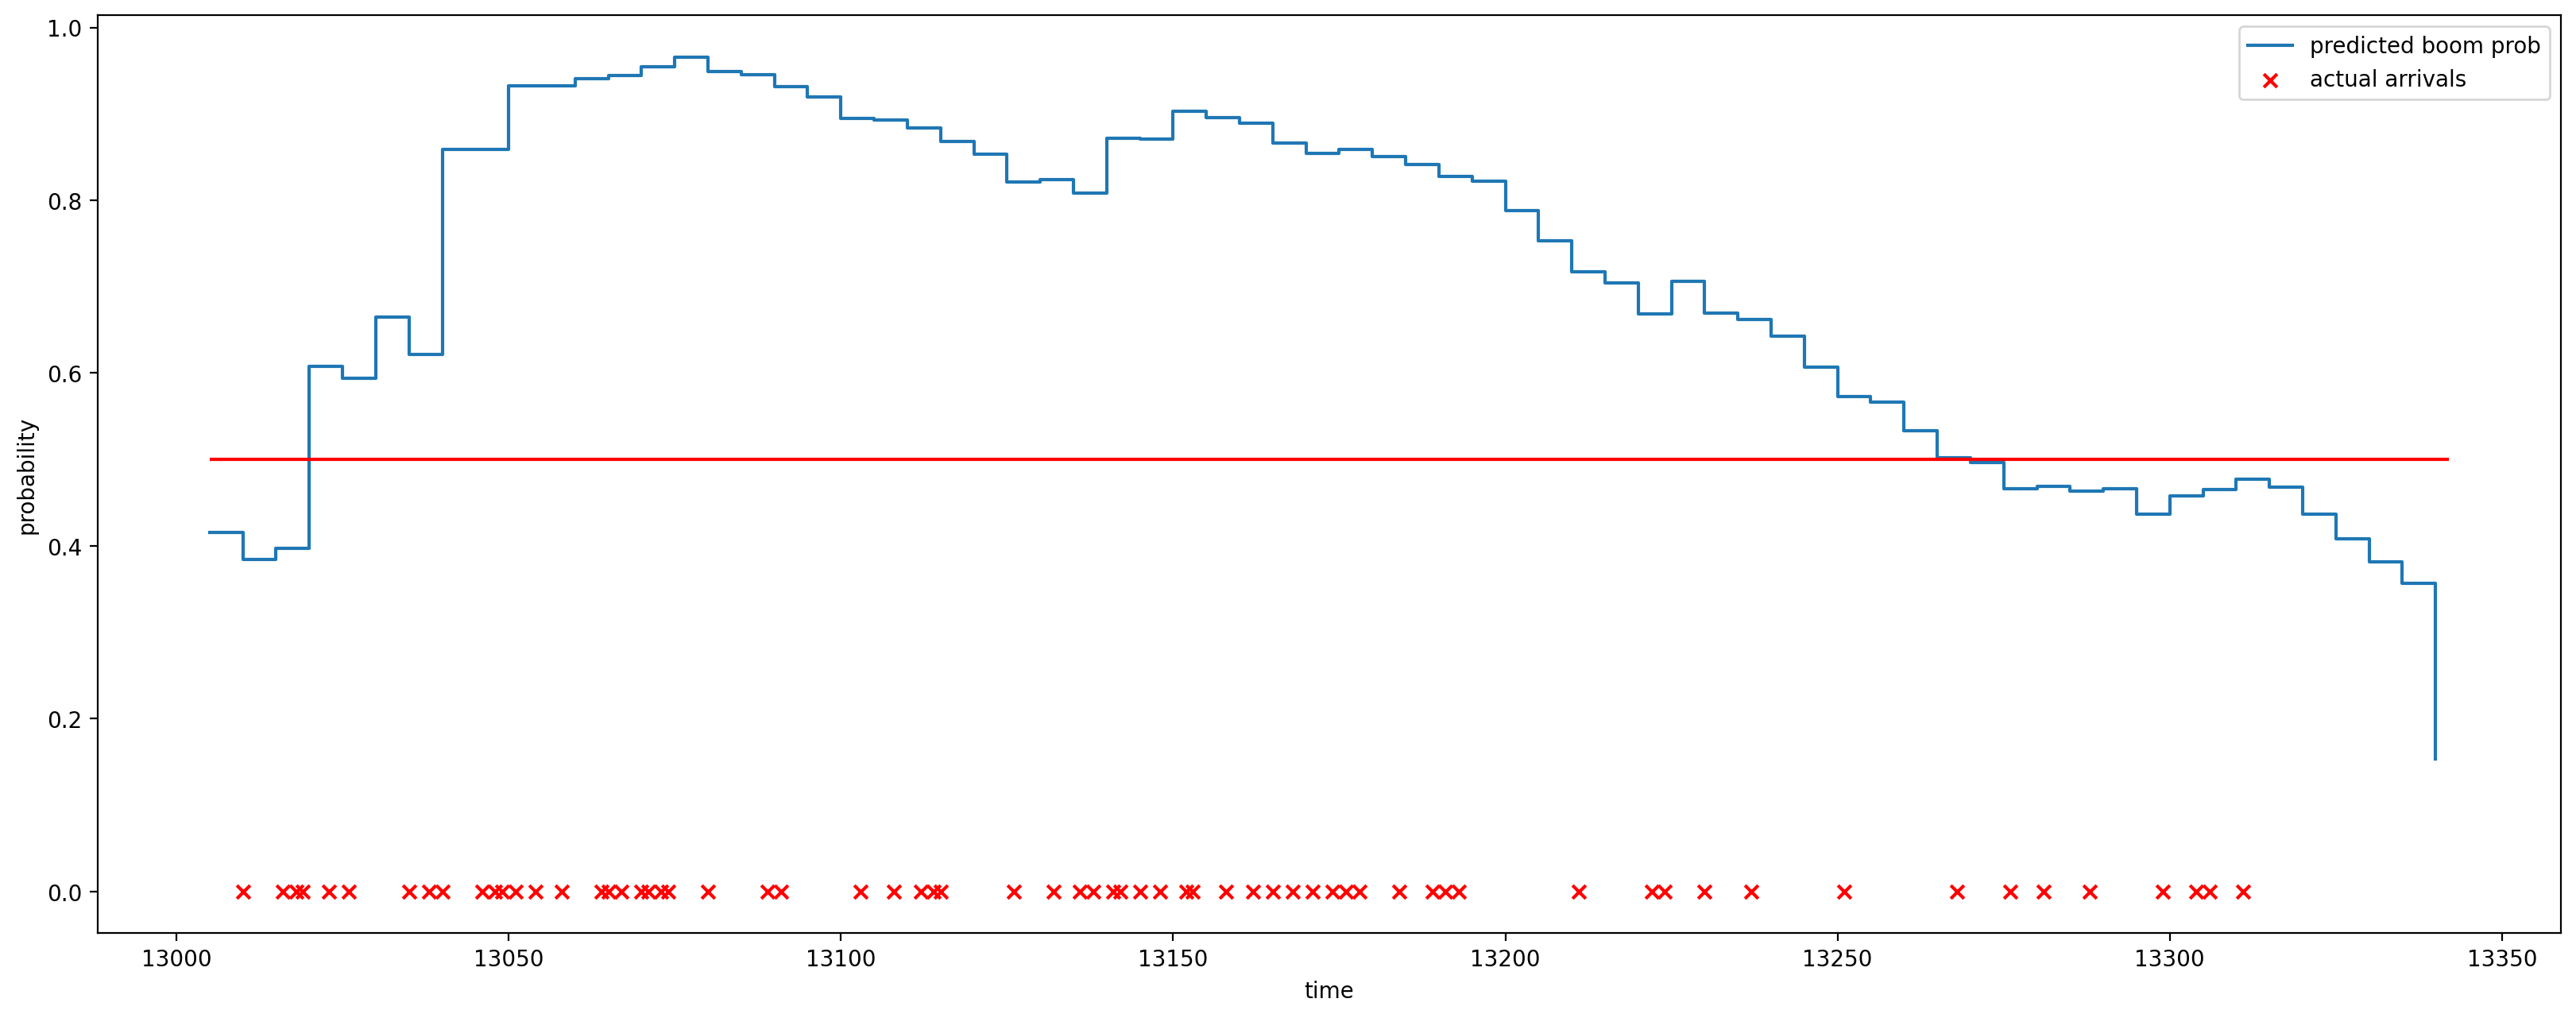

Estimated model parameters: [0.01197 0.00974 0.00496 4.69896 1.48538 0.15396 0.56765]
Log-likelihood: -2780.6850404642005
QPS: 0.3882064880963582
LPS: 0.577783838195411
--------------------------------------------------
Fitting model: Pow, None, SE GPD...
Fitted model: Pow, None, SE GPD!


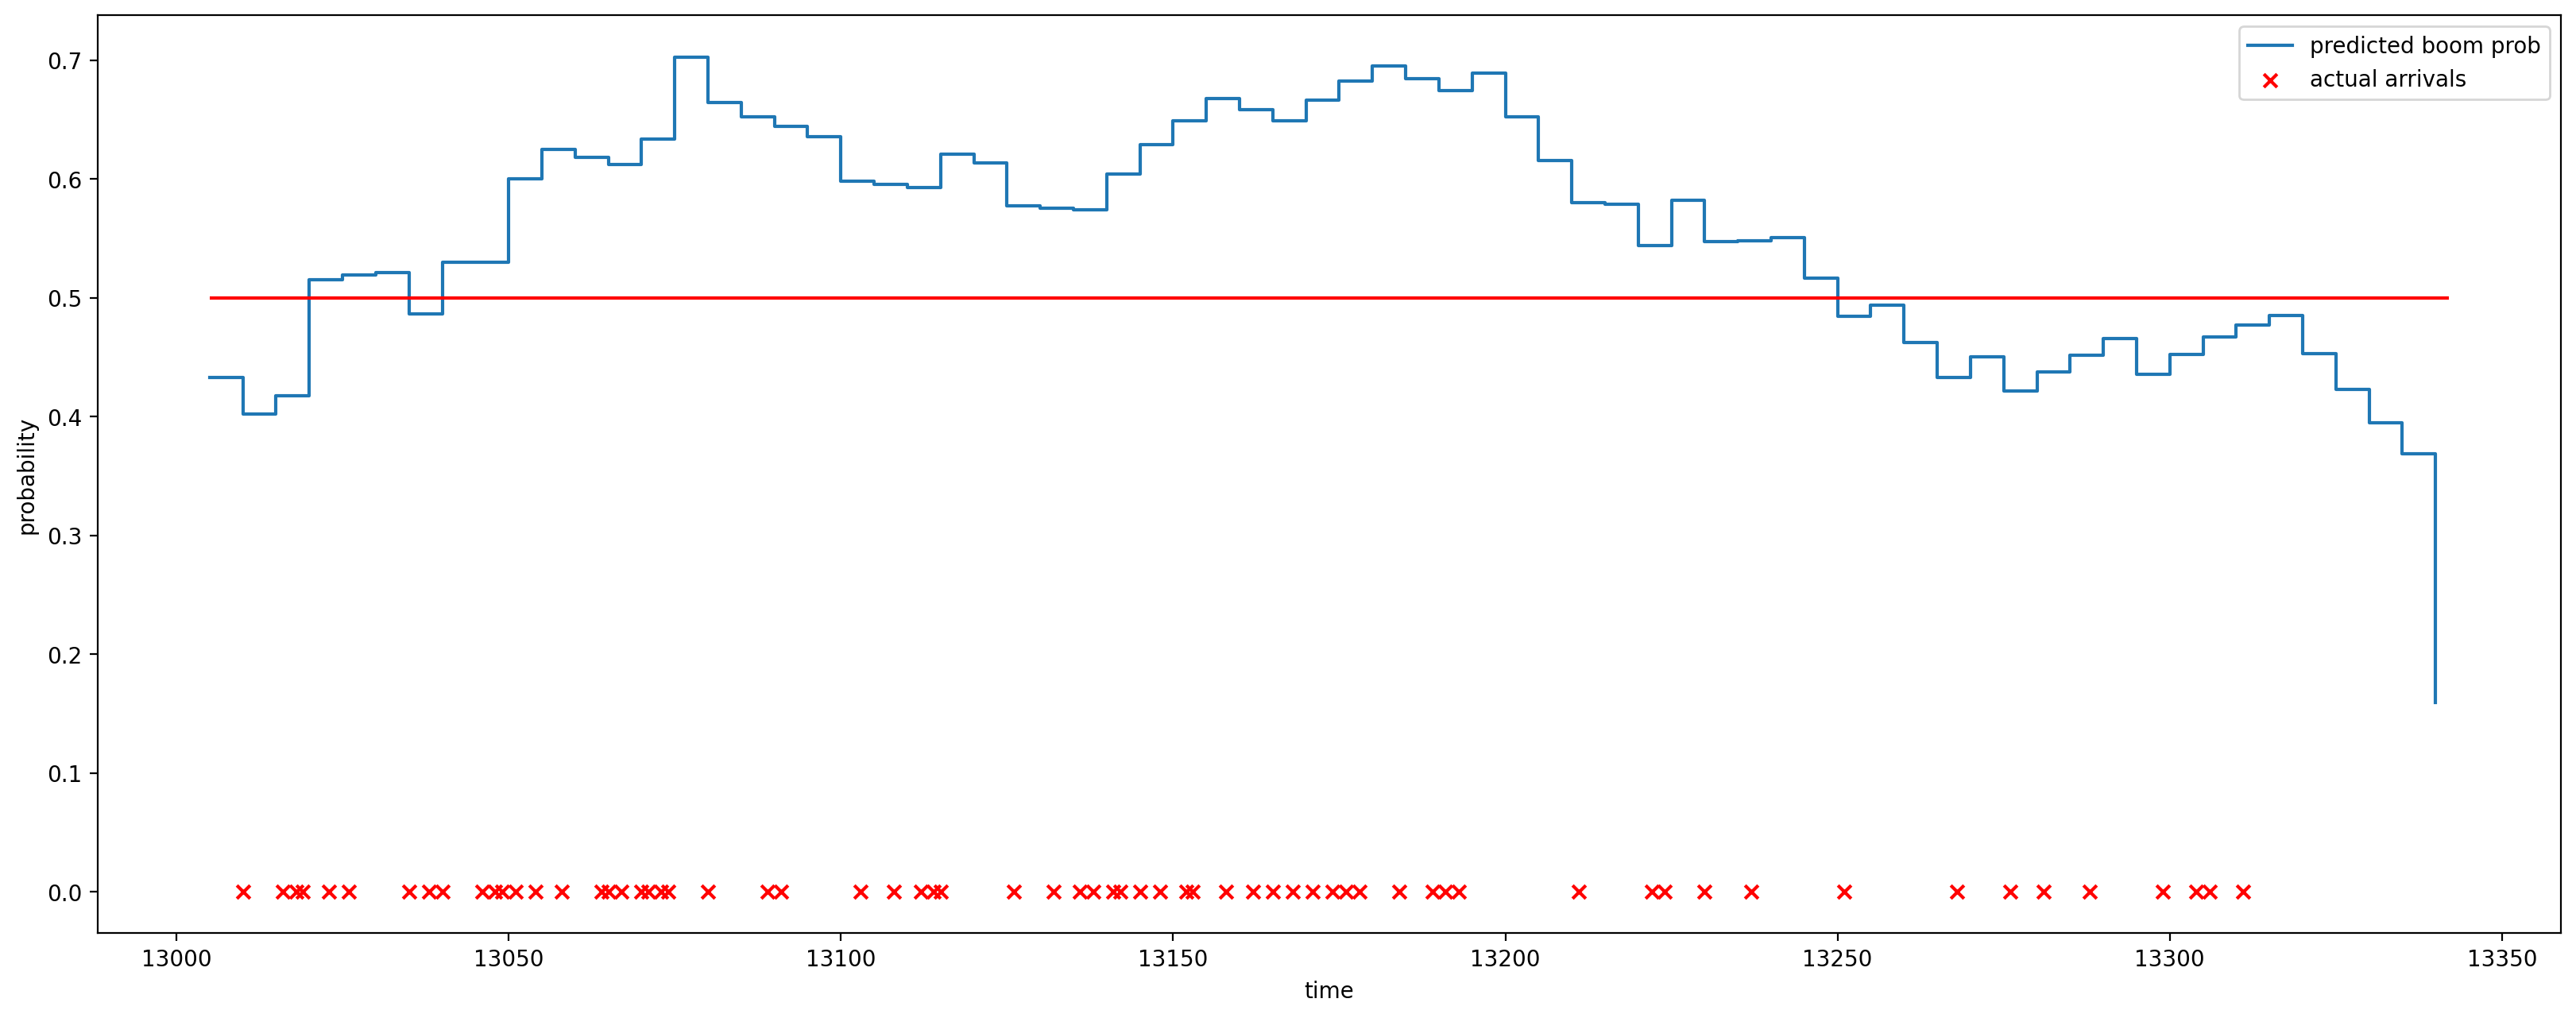

Estimated model parameters: [0.00889 0.01748 0.00367 5.73236 0.14331 0.36955 2.85375]
Log-likelihood: -2782.431176617354
QPS: 0.4408745582300236
LPS: 0.6319439228850994
--------------------------------------------------
Fitting model: Pow, Exp, SE GPD...
Fitted model: Pow, Exp, SE GPD!


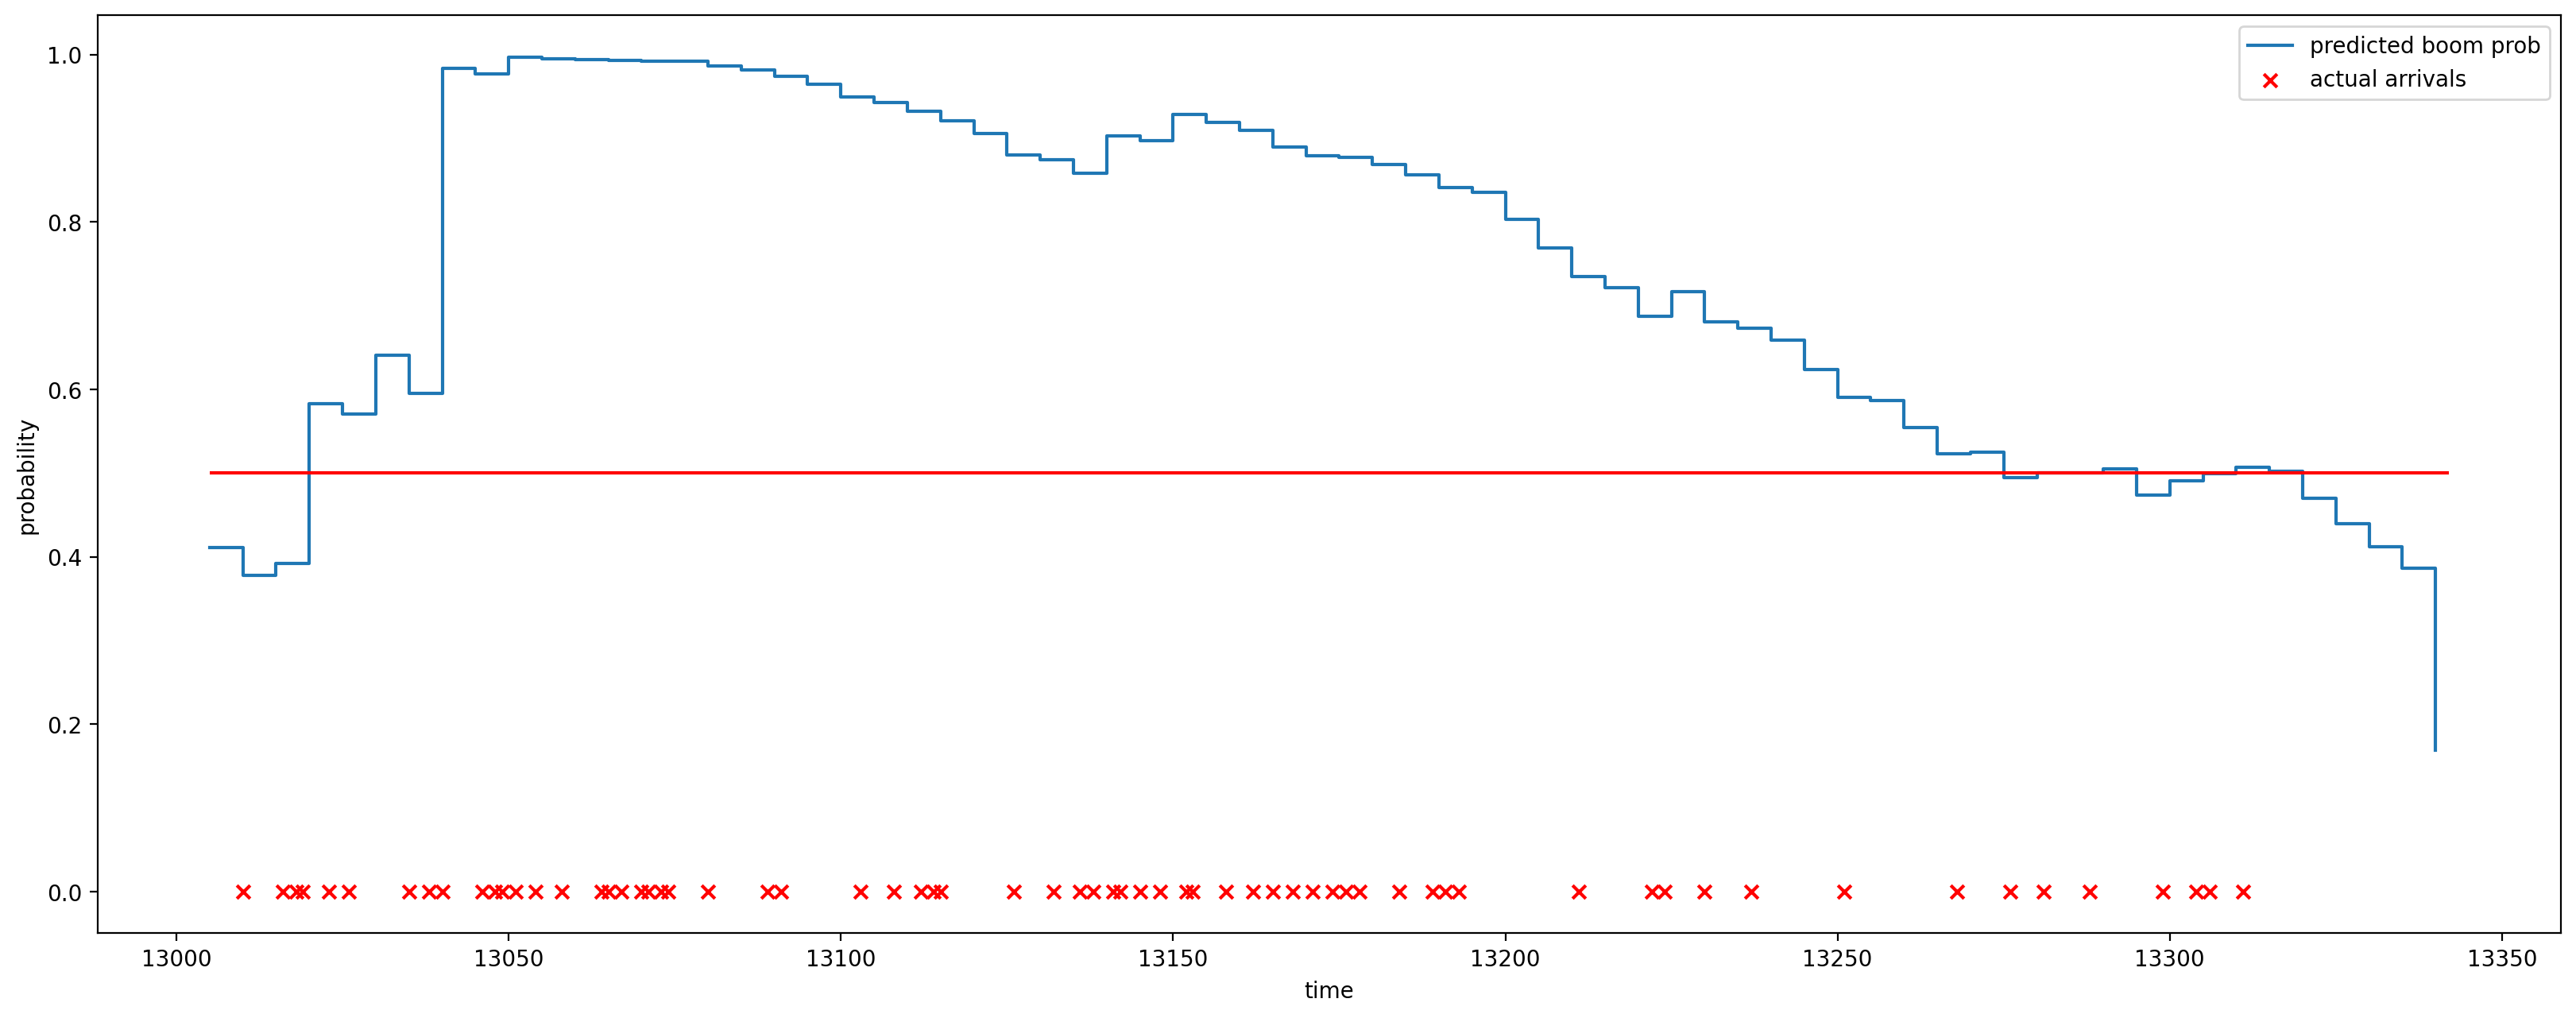

Estimated model parameters: [0.01092 0.01376 0.00742 3.2888  0.39993 0.13665 0.38181 2.59152]
Log-likelihood: -2767.0073574935777
QPS: 0.392783922147587
LPS: 0.6041864226105331
--------------------------------------------------
Fitting model: Pow, Pow, SE GPD...
Fitted model: Pow, Pow, SE GPD!


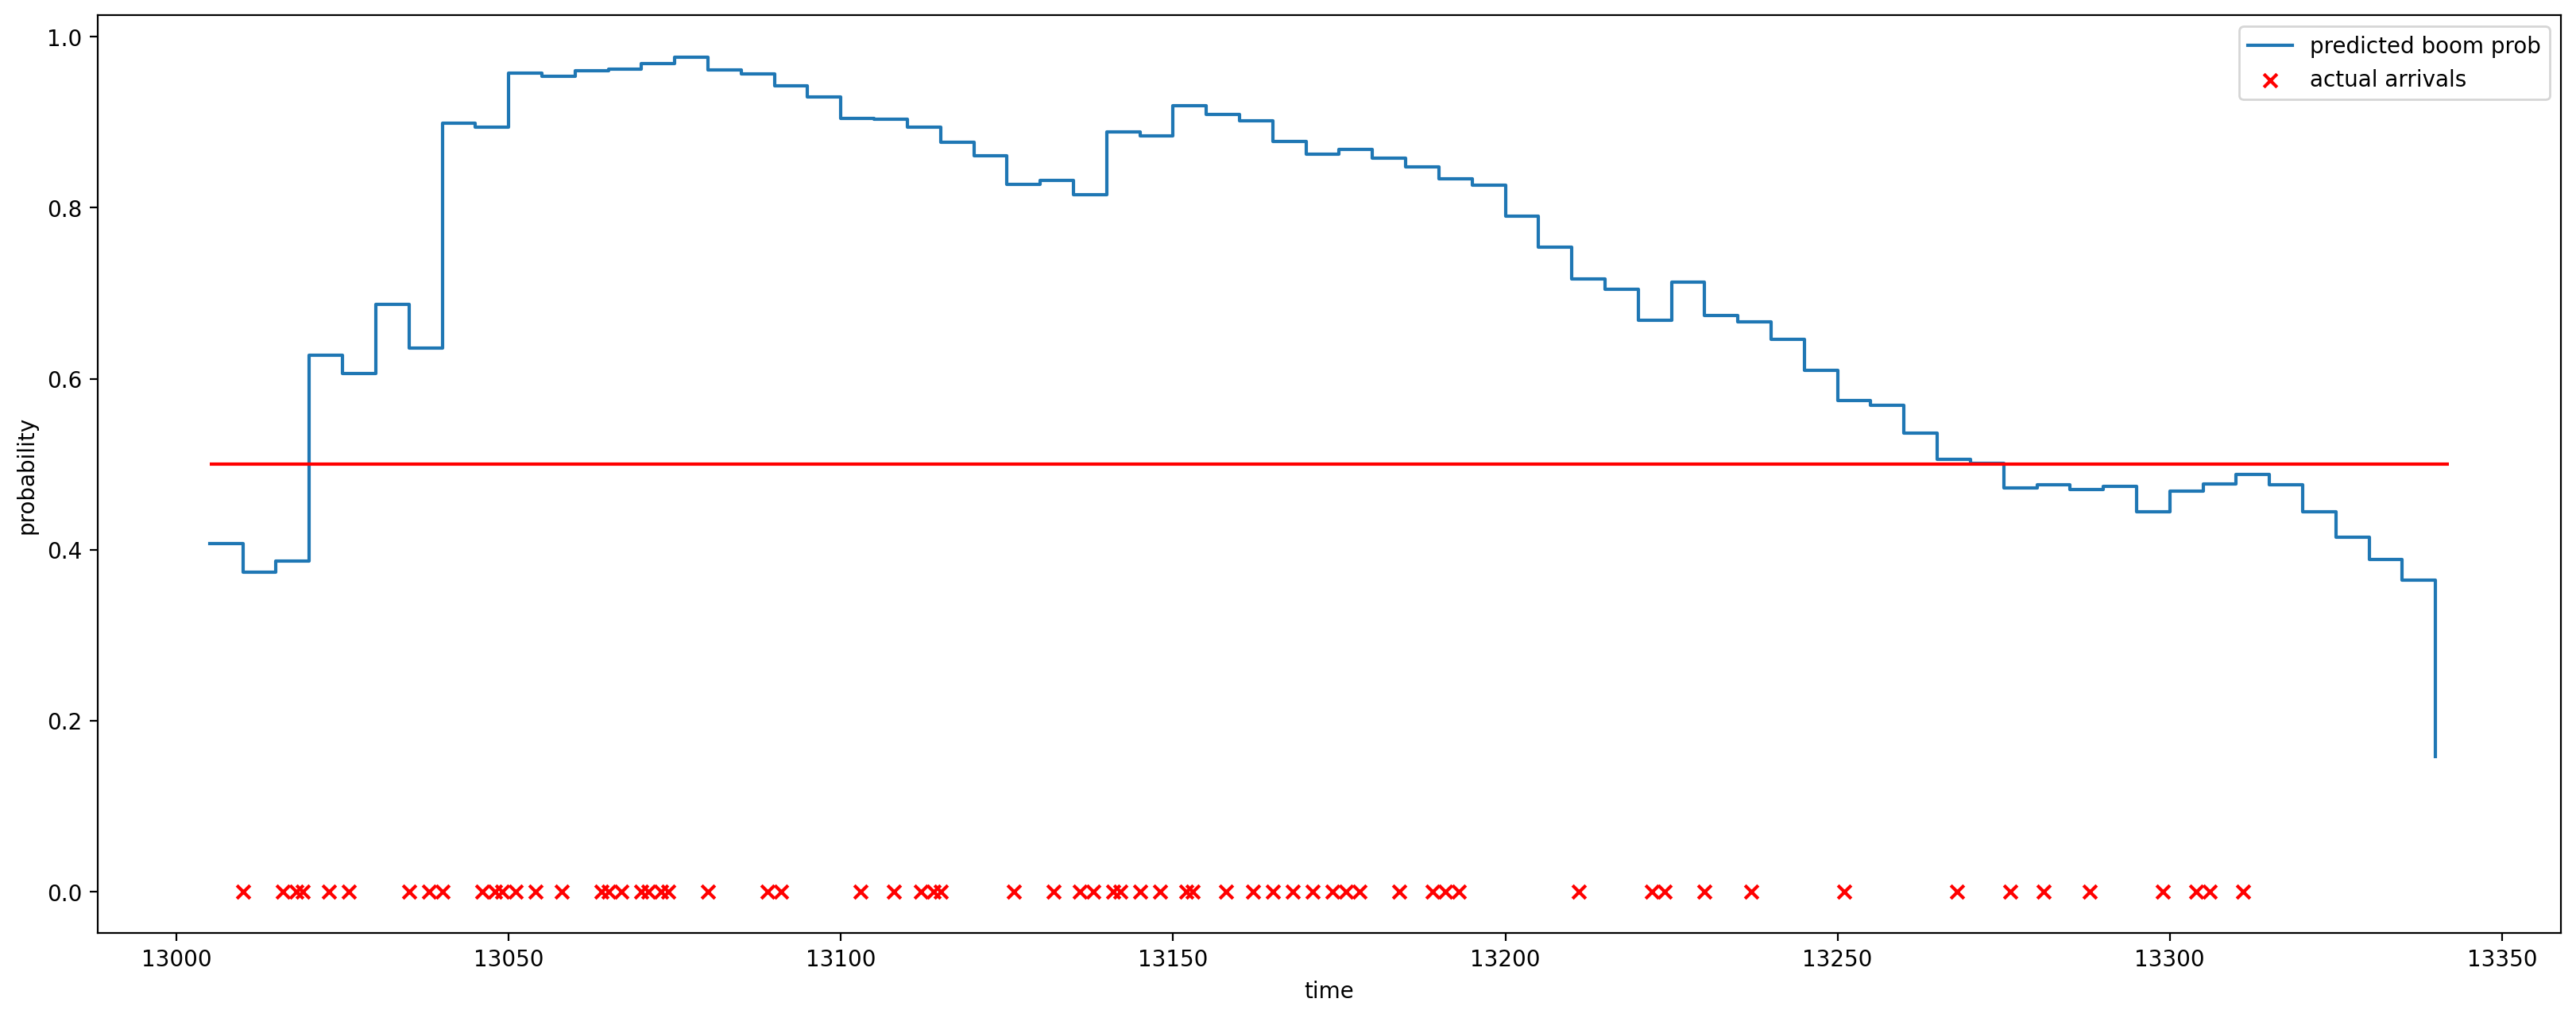

Estimated model parameters: [0.01226 0.01008 0.01005 2.59661 1.62733 0.1333  0.387   2.53652]
Log-likelihood: -2763.878148513306
QPS: 0.3880270420618528
LPS: 0.5806220962246532
--------------------------------------------------


In [10]:
SE_funs = ["Exp", "Pow"]
impact_funs = [None, "Exp", "Pow"]
mark_dists = ["GPD", "SE GPD"]

Results_df = pd.DataFrame()

Results_df.index = ["mu",
                    "K_0",
                    "gamma",
                    "omega",
                    "beta",
                    "alpha",
                    "xi",
                    "phi",
                    "eta",
                    "Branching ratio",
                    "log-like.",
                    "AIC",
                    "KS-test p-value",
                    "KS-test statistic",
                    "QPS on Test Set",
                    "LPS on Test Set"]


for SE_fun in SE_funs:
    for mark_dist in mark_dists:
        for impact_fun in impact_funs:


            SEPOT_model = SEPOT(SE_fun=SE_fun,
                                impact_fun=impact_fun,
                                mark_dist=mark_dist,
                                arrival_times=arrival_times_booms_train,
                                marks=marks_booms_train,
                                T=T_train,
                                threshold=boom_M0)
            
            print(f"Fitting model: {SE_fun}, {impact_fun}, {mark_dist}...")

            
            res = SEPOT_model.fit(method="L-BFGS-B",
                                  reparam=True,
                                  xi_pos=True,
                                  seed=1)
            
            print(f"Fitted model: {SE_fun}, {impact_fun}, {mark_dist}!")
            
            est_params = res.x

            log_likelihood = -res.fun
            AIC = 2 * len(est_params) - 2 * (log_likelihood)

            tau_i_s = SEPOT_model.compensator(starts=np.zeros(shape=(len(arrival_times_booms_train), ), dtype=float),
                                              ends=arrival_times_booms_train,
                                              params=est_params)

            interarrival_times = tau_i_s - np.concatenate([[0],
                                                            tau_i_s[:-1]])

            pvalue = kstest(rvs=interarrival_times,
                            cdf="expon").pvalue
            test_stat = kstest(rvs=interarrival_times,
                            cdf="expon").statistic
            
            Results_df[f"{SE_fun}, {impact_fun}, {mark_dist}"] = pd.Series("-",
                                                                           index=Results_df.index,
                                                                           dtype=object)

            if SE_fun == "Exp":
                Results_df.loc["Branching ratio", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[1]/est_params[2]
            else:
                Results_df.loc["Branching ratio", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[1]/(est_params[2] * est_params[3])

            Results_df.loc["log-like.", f"{SE_fun}, {impact_fun}, {mark_dist}"] = log_likelihood
            Results_df.loc["AIC", f"{SE_fun}, {impact_fun}, {mark_dist}"] = AIC
            Results_df.loc["KS-test p-value", f"{SE_fun}, {impact_fun}, {mark_dist}"] = pvalue
            Results_df.loc["KS-test statistic", f"{SE_fun}, {impact_fun}, {mark_dist}"] = test_stat

            Results_df.loc["mu", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[0]
            Results_df.loc["K_0", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[1]
            if SE_fun == "Exp":
                Results_df.loc["beta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[2]
                if impact_fun is not None:
                    Results_df.loc["alpha", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[3]
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[6]
                else:
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[3]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]

            else:
                Results_df.loc["gamma", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[2]
                Results_df.loc["omega", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[3]
                if impact_fun is not None:
                    Results_df.loc["alpha", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[6]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[7]
                else:
                    Results_df.loc["xi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[4]
                    Results_df.loc["phi", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[5]
                    if mark_dist == "SE GPD":
                        Results_df.loc["eta", f"{SE_fun}, {impact_fun}, {mark_dist}"] = est_params[6]

            preds, y = SEPOT_model.rolling_forecast(start=T_train,
                                                    days=5,
                                                    params=est_params,
                                                    test_arrival_times=arrival_times_booms_test,
                                                    test_marks=marks_booms_test,
                                                    test_T=T_test)
            
            
            QPS = 2/len(y) * ((preds - y)**2).sum()
            LPS = -1/len(y) * ((1 - y) * np.log(1 - preds) + y * np.log(preds)).sum()

            Results_df.loc["QPS on Test Set", f"{SE_fun}, {impact_fun}, {mark_dist}"] = QPS
            Results_df.loc["LPS on Test Set", f"{SE_fun}, {impact_fun}, {mark_dist}"] = LPS

            chunk_starts = np.arange(T_train, T_test, 5)[:len(preds)]
            chunk_centers = chunk_starts + 2.5

            chunk_starts = np.arange(T_train, T_test, 5)[:len(preds)]
            chunk_ends = np.minimum(chunk_starts + 5, T_test)

            plt.figure(figsize=(20, 7.5), dpi=100)
            plt.step(chunk_starts, preds, where='post', label='predicted boom prob')
            plt.scatter(arrival_times_booms_test, np.zeros_like(arrival_times_booms_test),
                        color='red', marker='x', label='actual arrivals')
            plt.hlines(y=0.5,
                       xmin=T_train,
                       xmax=T_test,
                       color="red")
            plt.xlabel('time')
            plt.ylabel('probability')
            plt.legend()
            plt.show()
            
            print(f"Estimated model parameters: {est_params}")
            print(f"Log-likelihood: {log_likelihood}")
            print(f"QPS: {QPS}")
            print(f"LPS: {LPS}")
            print("-"*50)


In [11]:
Results_df

,"Exp, None, GPD","Exp, Exp, GPD","Exp, Pow, GPD","Exp, None, SE GPD","Exp, Exp, SE GPD","Exp, Pow, SE GPD","Pow, None, GPD","Pow, Exp, GPD","Pow, Pow, GPD","Pow, None, SE GPD","Pow, Exp, SE GPD","Pow, Pow, SE GPD"
mu,0.00919,0.01130,0.01246,0.00935,0.01169,0.01319,0.00901,0.01095,0.01197,0.00889,0.01092,0.01226
K_0,0.01582,0.01186,0.00901,0.01631,0.01225,0.00884,0.01623,0.01257,0.00974,0.01748,0.01376,0.01008
gamma,-,-,-,-,-,-,0.00128,0.00317,0.00496,0.00367,0.00742,0.01005
omega,-,-,-,-,-,-,15.28626,6.91841,4.69896,5.73236,3.28880,2.59661
beta,0.01917,0.02085,0.02161,0.01985,0.02210,0.02308,-,-,-,-,-,-
alpha,-,0.38156,1.46422,-,0.39564,1.59122,-,0.38358,1.48538,-,0.39993,1.62733
xi,0.15396,0.15396,0.15396,0.14416,0.13865,0.13595,0.15396,0.15396,0.15396,0.14331,0.13665,0.13330
phi,0.56765,0.56765,0.56765,0.37227,0.38568,0.39099,0.56765,0.56765,0.56765,0.36955,0.38181,0.38700
eta,-,-,-,2.82623,2.54929,2.49642,-,-,-,2.85375,2.59152,2.53652
Branching ratio,0.82515,0.56871,0.41682,0.82177,0.55413,0.38278,0.82891,0.57306,0.41821,0.83188,0.56358,0.38608
